## Automatic Weather Station Manuela Data Introduction 

Information and data for AWS Manuela can be found [here](https://amrc.ssec.wisc.edu/aws/index.php?region=Reeves%20Glacier&year=2025&mode=uw). Briefly, AWS Manuela provides consistent time series data from 2012-present. The data of interest for Terra Nova Bay HSSW research include wind speed and direction. Wind speed and direction data are provided at 10 minute outputs. Note that missing data / bad data seems to be filled with the value 444.0 - but this should be verified. 


This notebook loads .txt files downloaded from AWS Manuela for the years 1987-2025, however consistent coverage does not begin until 2012, and converts the files to an xarray dataset and corresponding netcdf file format. I then go on to explore several questions regarding interannual variability and katabatic winds. These questions include: 

1. **What are the decadal means in wind speed and wind direction on a monthly and seasonal basis?**

2. **Which years were anomalously high and low relative to the decadal average?** 

3. **What are the monthly and seasonal means for each year?**

4. **What is the frequency (i.e how often do they occur) and magnitude of katabatic winds?** 

5. **For each year, which month has the highest frequency of katabatic wind speeds (> 25 m/s)?**

6. **How can we partition the data into katabatic wind events? What is the frequency and duration of such events?** 

In [2]:
# import packages 
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import xarray as xr 
import scipy
import matplotlib.dates as mdates
# import proplot

### 1. Convert txt files to netcdf

In [2]:
# load all txt files in the yearly subfolders within the base_path
from glob import glob

# Base folder path (replace with your actual base directory)
base_path = "/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/AWS_Manuela"

# List of years you want to search
years = range(1987, 2026)  # Inclusive of 2025

# Initialize empty list
txt_files = []

# Loop through each year and collect .txt files
for year in years:
    year_path = f"{base_path}/{year}/*.txt"
    txt_files.extend(glob(year_path))

# Print or use the combined list
print(f"Found {len(txt_files)} .txt files:")
for file in txt_files:
    print(file)


Found 279 .txt files:
/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/AWS_Manuela/2001/mla200112q10.txt
/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/AWS_Manuela/2001/mla200110q10.txt
/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/AWS_Manuela/2001/mla200109q10.txt
/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/AWS_Manuela/2001/mla200111q10.txt
/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/AWS_Manuela/2002/mla200209q10.txt
/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/AWS_Manuela/2002/mla200205q10.txt
/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/AWS_Manuela/2002/mla200207q10.txt
/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/AWS_Manuela/2002/mla200211q10.txt
/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/AWS_Manuela/2002/mla200203q10.txt
/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/AWS_Manuela/2002/mla200201q10.txt
/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/

In [3]:
# Process txt files and save xarray datasets into a list 

# define empty list to append to 
data_interpolated = []
for i in range(len(txt_files)):
    # load txt file into pandas dataframe 
    df = pd.read_csv(txt_files[i], skiprows=2, delim_whitespace=True, header=None)
    # get dates first 
    dates = df.iloc[:,0:5]
    # rename columns to variable names 
    dates = dates.rename(columns={0: "year", 1: "julian day",
                        2: "month", 3: "day",
                        4: "time"})
    
    # time is stored as an integer (e.g., 10, 2350, etc.) - this must be split into hours and mins 
    # Make sure values are zero-padded to 4 digits first (e.g., 0010, 2350)
    dates['time_str'] = dates['time'].astype(str).str.zfill(4)
    
    # Split into hours and minutes
    dates['hour'] = dates['time_str'].str[:2].astype(int)
    dates['minute'] = dates['time_str'].str[2:].astype(int)

    # take data from dataframe --> numpy array 
    month = dates['month'].values
    day = dates['day'].values 
    year = dates['year'].values 
    hour = dates['hour'].values
    minute = dates['minute'].values

    
    # create a dataframe of dates using arrays from above 
    dates = pd.to_datetime(
                pd.DataFrame({'year': year, 'month': month, 'day': day,
                              'hour': hour, 'minute': minute})
                )

    # convert dates to numpy array 
    dates = dates.values

    # get data 
    data = df.iloc[:,5:11]
    # rename data columns 
    data = data.rename(columns={5:"temp",6:"pressure",7:"wind_speed",8:"wind_dir",9:"relative_humidity",10:"delta-temp"})
    # convert to xarray dataset 
    data = data.to_xarray()
    # add time 
    data['time'] = ('index',dates)
    # make time the dimension 
    data = data.swap_dims({'index':'time'})
    # Replace 444.0 with NaN
    data_cleaned = data.where(data != 444.0, np.nan)
    # Interpolate over NaNs for each variable along the 'time' dimension
    data_interpolated.append(data_cleaned.interpolate_na(dim="time", method="linear"))

/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_35866/3052900756.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(txt_files[i], skiprows=2, delim_whitespace=True, header=None)
/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_35866/3052900756.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(txt_files[i], skiprows=2, delim_whitespace=True, header=None)
/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_35866/3052900756.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(txt_files[i], skiprows=2, delim_whitespace=True, header=None)
/var/folders/yh/gzfzh54j7n572slt5126rl3m0000gn/T/ipykernel_35866/3052900756.py:7: Fut

In [4]:
# merge datasets from list into one dataset 
data = xr.merge(data_interpolated)

In [5]:
# data.to_netcdf('/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/AWS_Manuela/AWS_Manuela_2001_2025.nc')

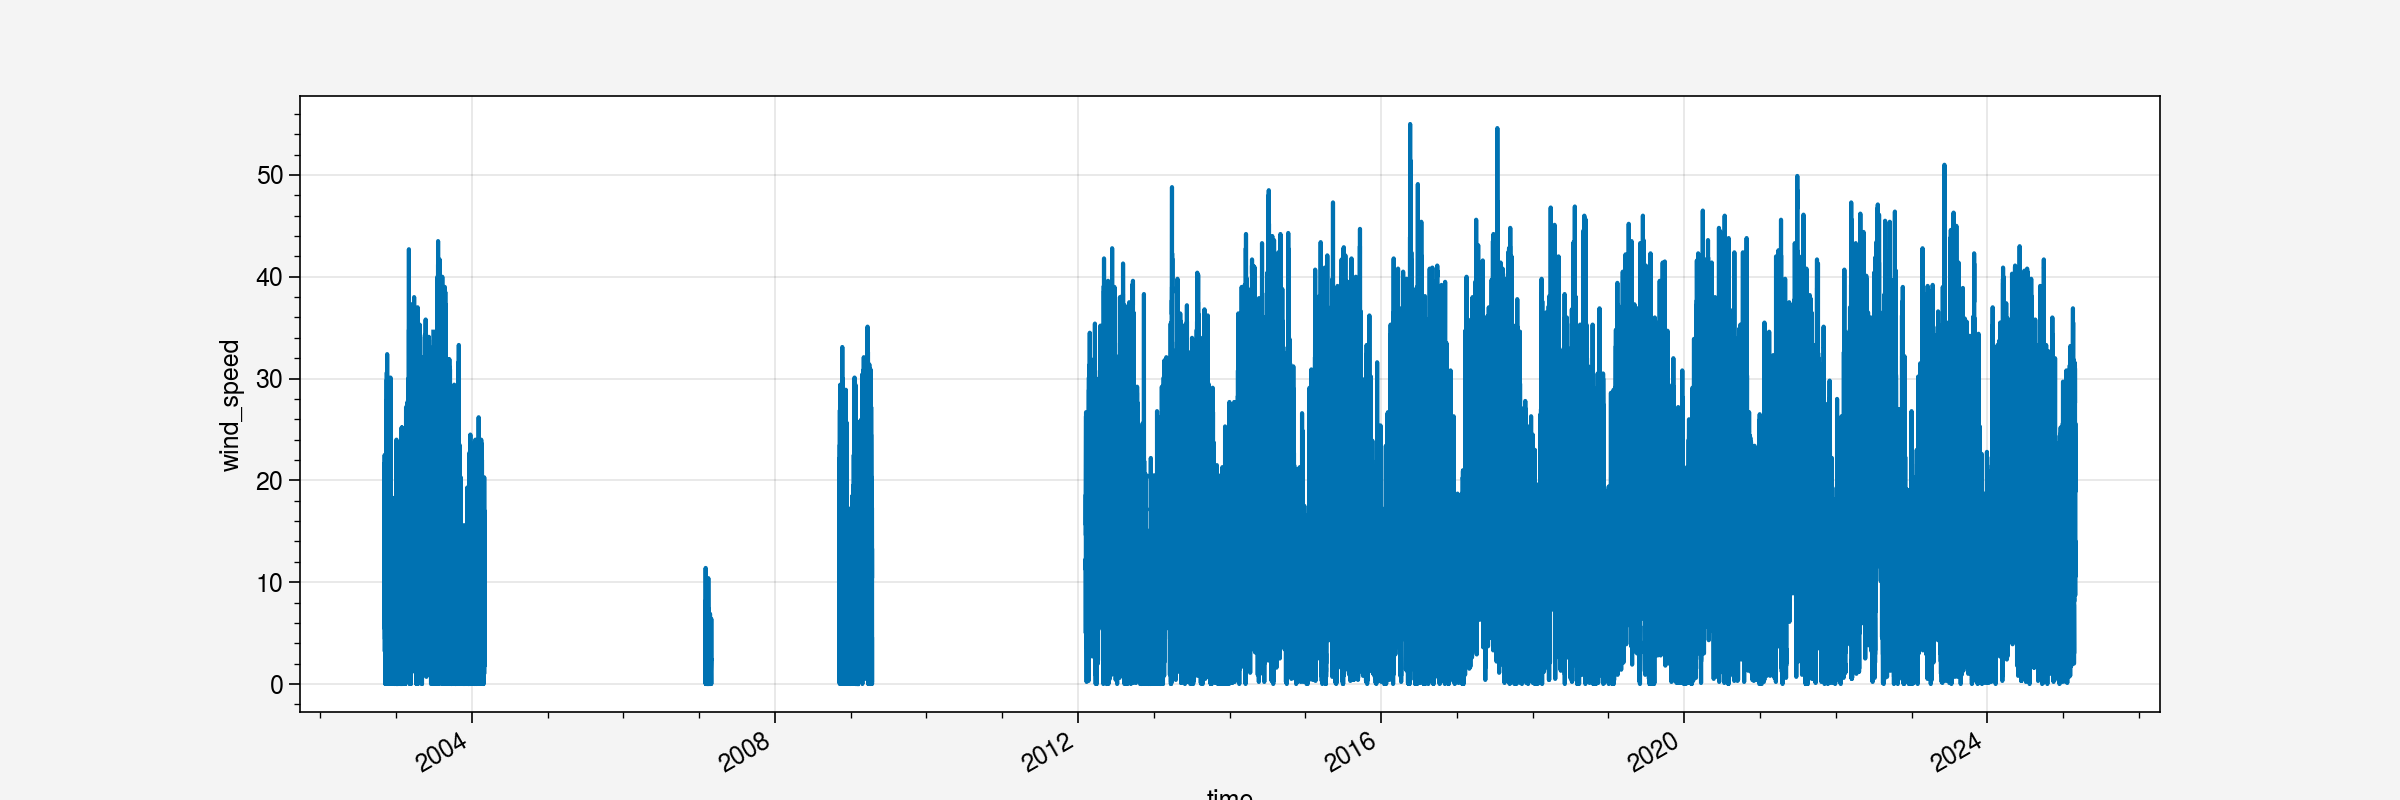

In [7]:
# first view of the data - notice inconsistency in measurments prior to 2012 
data.wind_speed.plot(figsize=(12,4))

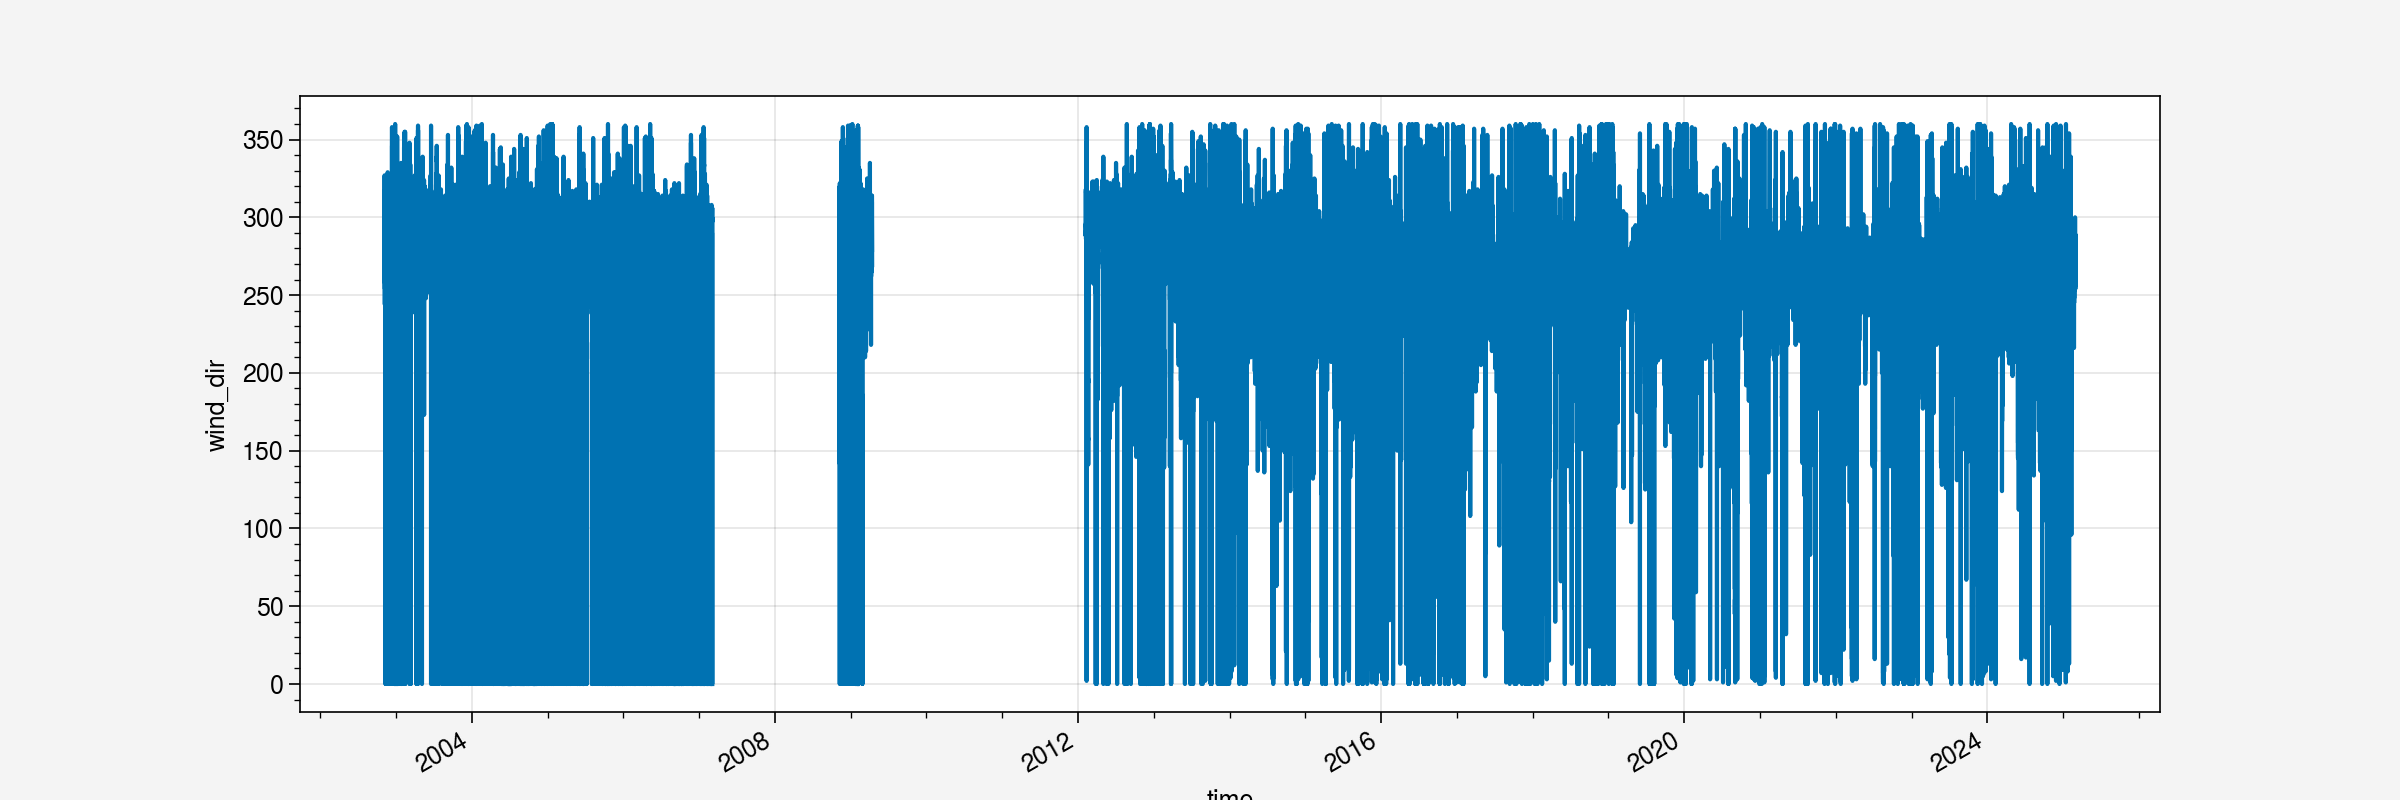

In [8]:
data.wind_dir.plot(figsize=(12,4))

### Piece-wise (for single txt file)

In [84]:
df = pd.read_csv("/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/AWS_Manuela/2010/mla201001q10.txt", skiprows=2, delim_whitespace=True, header=None)

In [85]:
df

,0,1,2,3,4,5,6,7,8,9,10
0,2010,1,1,1,0,-3.1,994.9,444.0,444.0,50.2,0.1
1,2010,1,1,1,10,-3.1,995.0,444.0,444.0,47.7,0.1
2,2010,1,1,1,20,-3.1,995.1,444.0,444.0,44.8,0.1
3,2010,1,1,1,30,-2.9,995.1,444.0,444.0,46.0,0.1
4,2010,1,1,1,40,-2.5,995.0,444.0,444.0,46.9,0.1
...,...,...,...,...,...,...,...,...,...,...,...
4459,2010,31,1,31,2310,-9.4,983.0,444.0,444.0,64.1,0.0
4460,2010,31,1,31,2320,-9.1,983.1,444.0,444.0,62.4,-0.2
4461,2010,31,1,31,2330,-9.0,983.8,444.0,444.0,62.0,0.1
4462,2010,31,1,31,2340,-8.9,984.2,444.0,444.0,62.4,1.1


In [39]:
# get dates first 
dates = df.iloc[:,0:5]

In [40]:
dates

,0,1,2,3,4
0,2017,1,1,1,0
1,2017,1,1,1,10
2,2017,1,1,1,20
3,2017,1,1,1,30
4,2017,1,1,1,40
...,...,...,...,...,...
4459,2017,31,1,31,2310
4460,2017,31,1,31,2320
4461,2017,31,1,31,2330
4462,2017,31,1,31,2340


In [41]:
# rename columns to variable names 
dates = dates.rename(columns={0: "year", 1: "julian day",
                        2: "month", 3: "day",
                        4: "time"})

In [42]:
dates

,year,julian day,month,day,time
0,2017,1,1,1,0
1,2017,1,1,1,10
2,2017,1,1,1,20
3,2017,1,1,1,30
4,2017,1,1,1,40
...,...,...,...,...,...
4459,2017,31,1,31,2310
4460,2017,31,1,31,2320
4461,2017,31,1,31,2330
4462,2017,31,1,31,2340


In [43]:
# Example: if time is stored as an integer (e.g., 10, 2350, etc.)
# Make sure values are zero-padded to 4 digits first (e.g., 0010, 2350)
dates['time_str'] = dates['time'].astype(str).str.zfill(4)

# Split into hours and minutes
dates['hour'] = dates['time_str'].str[:2].astype(int)
dates['minute'] = dates['time_str'].str[2:].astype(int)


In [44]:
dates

,year,julian day,month,day,time,time_str,hour,minute
0,2017,1,1,1,0,0000,0,0
1,2017,1,1,1,10,0010,0,10
2,2017,1,1,1,20,0020,0,20
3,2017,1,1,1,30,0030,0,30
4,2017,1,1,1,40,0040,0,40
...,...,...,...,...,...,...,...,...
4459,2017,31,1,31,2310,2310,23,10
4460,2017,31,1,31,2320,2320,23,20
4461,2017,31,1,31,2330,2330,23,30
4462,2017,31,1,31,2340,2340,23,40


In [45]:
# take data from dataframe --> numpy array 
month = dates['month'].values
day = dates['day'].values 
year = dates['year'].values 
hour = dates['hour'].values
minute = dates['minute'].values
# second = dates['second'].values 

In [46]:
# create a dataframe of dates using arrays from above 
dates = pd.to_datetime(
            pd.DataFrame({'year': year, 'month': month, 'day': day,
                          'hour': hour, 'minute': minute})
            )

In [47]:
dates

0      2017-01-01 00:00:00
1      2017-01-01 00:10:00
2      2017-01-01 00:20:00
3      2017-01-01 00:30:00
4      2017-01-01 00:40:00
               ...        
4459   2017-01-31 23:10:00
4460   2017-01-31 23:20:00
4461   2017-01-31 23:30:00
4462   2017-01-31 23:40:00
4463   2017-01-31 23:50:00
Length: 4464, dtype: datetime64[ns]

In [48]:
# convert dates to numpy array 
dates = dates.values

In [49]:
dates

array(['2017-01-01T00:00:00.000000000', '2017-01-01T00:10:00.000000000',
       '2017-01-01T00:20:00.000000000', ...,
       '2017-01-31T23:30:00.000000000', '2017-01-31T23:40:00.000000000',
       '2017-01-31T23:50:00.000000000'], dtype='datetime64[ns]')

In [50]:
# get data 
data = df.iloc[:,5:11]
data = data.rename(columns={5:"temp",6:"pressure",7:"wind_speed",8:"wind_dir",9:"relative_humidity",10:"delta-temp"})
data = data.to_xarray()
data['time'] = ('index',dates)
data = data.swap_dims({'index':'time'})
# Step 1: Replace -9999 with NaN
data_cleaned = data.where(data != 444.0, np.nan)

# Step 2: Interpolate over NaNs for each variable along the 'time' dimension
data_interpolated = data_cleaned.interpolate_na(dim="time", method="linear")


In [51]:
data

,5,6,7,8,9,10
0,-0.3,984.9,2.6,162.0,65.8,444.0
1,-0.3,984.9,2.7,168.0,66.0,444.0
2,0.0,984.8,2.7,167.0,64.0,444.0
3,0.2,984.8,2.6,173.0,64.0,444.0
4,-0.2,984.8,3.2,205.0,64.0,444.0
...,...,...,...,...,...,...
4459,-4.5,993.8,0.6,262.0,62.0,444.0
4460,-4.8,993.9,1.2,262.0,61.0,444.0
4461,-4.6,993.8,1.2,260.0,59.0,444.0
4462,-4.5,993.8,1.1,259.0,57.0,444.0


In [52]:
data = data.rename(columns={5:"temp",6:"pressure",7:"wind_speed",8:"wind_dir",9:"relative_humidity",10:"delta-temp"})

In [53]:
data

,temp,pressure,wind_speed,wind_dir,relative_humidity,delta-temp
0,-0.3,984.9,2.6,162.0,65.8,444.0
1,-0.3,984.9,2.7,168.0,66.0,444.0
2,0.0,984.8,2.7,167.0,64.0,444.0
3,0.2,984.8,2.6,173.0,64.0,444.0
4,-0.2,984.8,3.2,205.0,64.0,444.0
...,...,...,...,...,...,...
4459,-4.5,993.8,0.6,262.0,62.0,444.0
4460,-4.8,993.9,1.2,262.0,61.0,444.0
4461,-4.6,993.8,1.2,260.0,59.0,444.0
4462,-4.5,993.8,1.1,259.0,57.0,444.0


In [54]:
data = data.to_xarray()

In [55]:
data['time'] = ('index',dates)

In [56]:
data

<xarray.Dataset>
Dimensions:            (index: 4464)
Coordinates:
  * index              (index) int64 0 1 2 3 4 5 ... 4459 4460 4461 4462 4463
Data variables:
    temp               (index) float64 -0.3 -0.3 0.0 0.2 ... -4.6 -4.5 444.0
    pressure           (index) float64 984.9 984.9 984.8 ... 993.8 993.8 444.0
    wind_speed         (index) float64 2.6 2.7 2.7 2.6 3.2 ... 1.2 1.2 1.1 444.0
    wind_dir           (index) float64 162.0 168.0 167.0 ... 260.0 259.0 444.0
    relative_humidity  (index) float64 65.8 66.0 64.0 64.0 ... 59.0 57.0 444.0
    delta-temp         (index) float64 444.0 444.0 444.0 ... 444.0 444.0 444.0
    time               (index) datetime64[ns] 2017-01-01 ... 2017-01-31T23:50:00

In [57]:
data = data.swap_dims({'index':'time'})

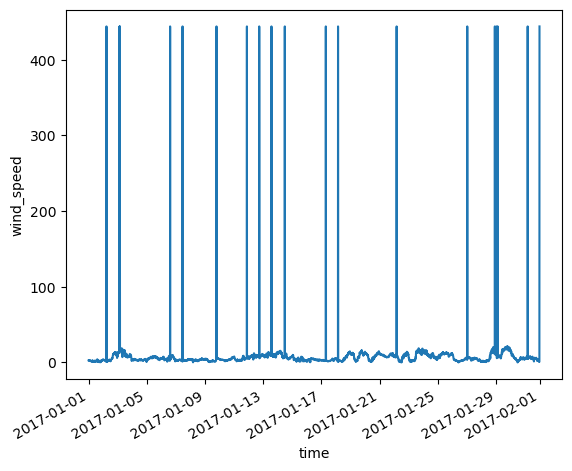

In [59]:
data.wind_speed.plot()

In [61]:
data.where(data.wind_speed == 444.0,drop=True)

<xarray.Dataset>
Dimensions:            (time: 19)
Coordinates:
    index              (time) int64 177 307 309 807 930 ... 4038 4049 4346 4463
  * time               (time) datetime64[ns] 2017-01-02T05:30:00 ... 2017-01-...
Data variables:
    temp               (time) float64 0.3 0.8 0.6 -2.4 ... 444.0 -4.1 444.0
    pressure           (time) float64 980.9 968.6 967.8 ... 444.0 987.7 444.0
    wind_speed         (time) float64 444.0 444.0 444.0 ... 444.0 444.0 444.0
    wind_dir           (time) float64 444.0 444.0 444.0 ... 444.0 444.0 444.0
    relative_humidity  (time) float64 61.0 42.0 40.3 62.0 ... 444.0 74.0 444.0
    delta-temp         (time) float64 444.0 444.0 444.0 ... 444.0 444.0 444.0

In [62]:
# Step 1: Replace -9999 with NaN
data_cleaned = data.where(data != 444.0, np.nan)

# Step 2: Interpolate over NaNs for each variable along the 'time' dimension
data_interpolated = data_cleaned.interpolate_na(dim="time", method="linear")

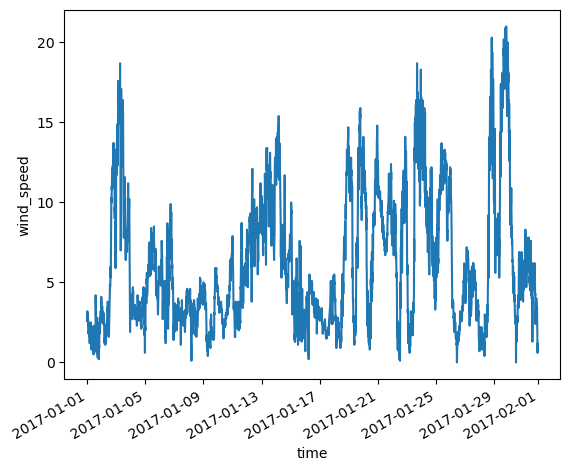

In [64]:
data_interpolated.wind_speed.plot()

### Explore Interannual Variability 

In [3]:
# open data
ds = xr.open_dataset('/Users/mackenzie/Documents/Research/PhD/TNB_Research/data/AWS_Manuela/AWS_Manuela_2001_2025.nc')

In [17]:
# there is inconsistent data prior to 2012
# select 2012 to present 
ds = ds.sel(time=slice('2012','2024'))

In [18]:
# dt = 10 mintues 
ds

<xarray.Dataset> Size: 43MB
Dimensions:            (time: 679392)
Coordinates:
  * time               (time) datetime64[ns] 5MB 2012-02-01 ... 2024-12-31T23...
    index              (time) float64 5MB ...
Data variables:
    temp               (time) float64 5MB ...
    pressure           (time) float64 5MB ...
    wind_speed         (time) float64 5MB nan nan nan nan ... 12.9 11.3 nan nan
    wind_dir           (time) float64 5MB ...
    relative_humidity  (time) float64 5MB ...
    delta-temp         (time) float64 5MB ...

#### Time Series Plots 

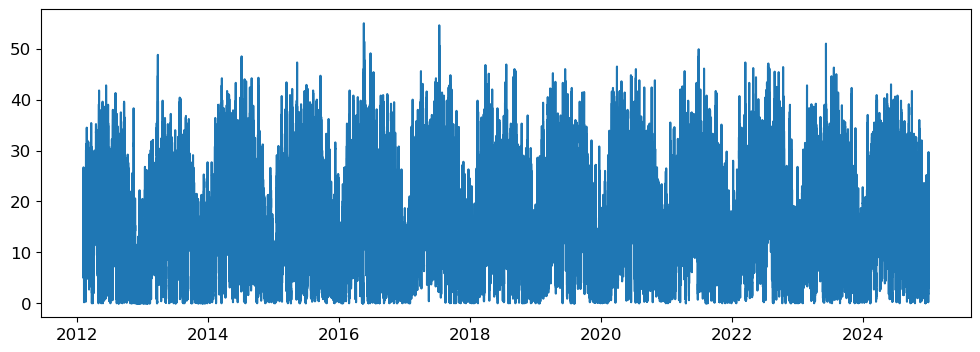

In [19]:
# plot full time series (no averaging)
fig = plt.figure(figsize=(12,4))

plt.plot(ds.time,ds.wind_speed)

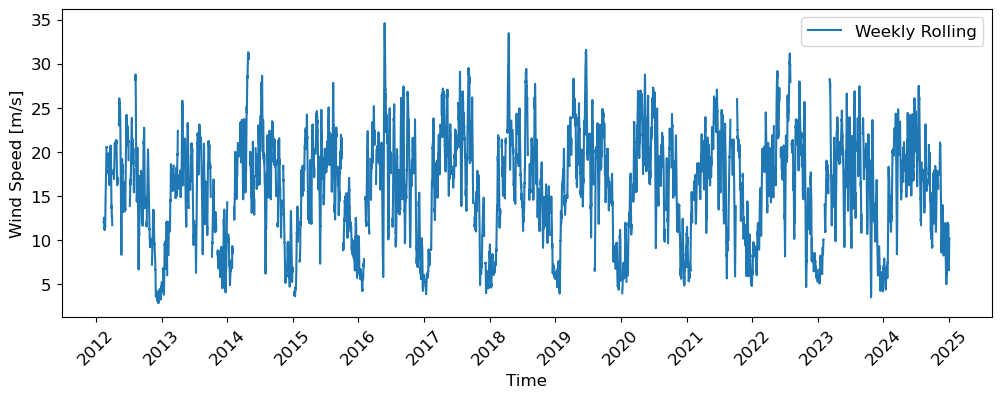

In [20]:
plt.rcParams['font.size'] = 12
fig = plt.figure(figsize=(12,4))
plt.plot(ds.time,ds.wind_speed.rolling(time=1008).mean(),label='Weekly Rolling',linestyle='-')
#plt.plot(ds.time,ds.wind_speed.rolling(time=4032).mean(),label='Monthly Rolling')
plt.legend()
plt.xlabel('Time')
plt.ylabel('Wind Speed [m/s]')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator());
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'));

plt.xticks(rotation=45);

# plt.savefig('/Users/mackenzie/Documents/Research/PhD/TNB_Research/Figures/AWS_Manuela/wspd_timeseries_weeklyrolling.png',
#             dpi=400,
#             bbox_inches='tight',
#             transparent=True)

Low and high frequency variability is evident in the fourteen year time series of wind speed (Figure 1). Low frequency variability is illustrated by the annual cycle with wind speeds gradually rising at the start of the year as austral fall approaches. Wind speed reaches a maximum mid year in the peak of winter (JJA) and then gradually declines through spring until reaching minimum values in summer (DJF). High frequency variability surrounds the annual cycle, appearing as spikes, corresponding to changes in wind speed on shorter timescales. No trend is evident that would suggest a mean increase or decrease in wind speed since 2012, however, there are some years that have higher peaks at shorter timescales such as 2016, 2018, and 2019. 

(0.0, 0.04549211507159538)

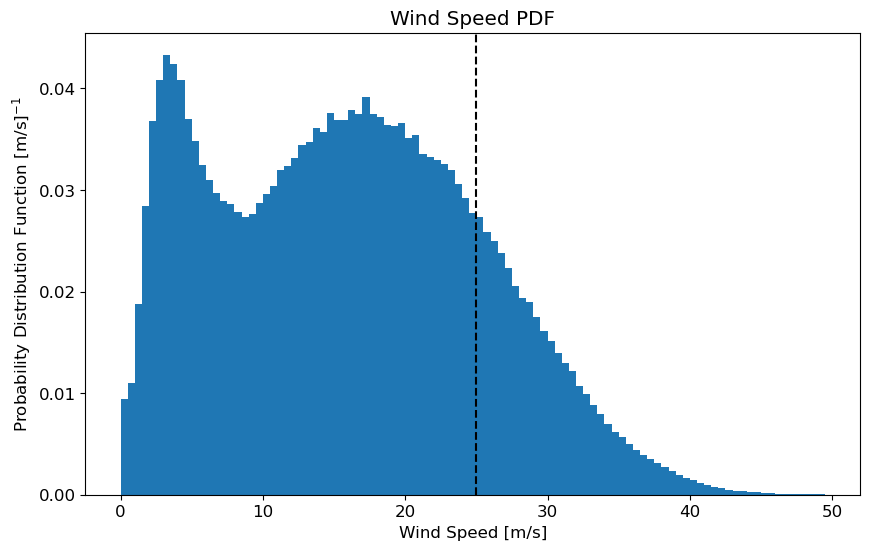

In [21]:
fig = plt.figure(figsize=(10,6))
bmin, bmax, dbins = (0,50,0.5)
bins = np.arange(bmin,bmax,dbins)
plt.hist(ds.wind_speed,density=True,bins=bins);
plt.title('Wind Speed PDF')
plt.ylabel(r'Probability Distribution Function [m/s]$^{-1}$')
plt.xlabel('Wind Speed [m/s]')
y_start, y_stop = plt.ylim()
plt.vlines(x=25,ymin=y_start,ymax=y_stop,linestyle='dashed',color='k')
plt.ylim(y_start,y_stop)

# plt.savefig('/Users/mackenzie/Documents/Research/PhD/TNB_Research/Figures/AWS_Manuela/wspd_pdf.png',
#             dpi=400,
#             bbox_inches='tight',
#             transparent=True)

The above plot shows the probability distribution for wind speed. The PDF is characterized by two peaks one at lower wind speed (5 m/s) and one at moderate wind speeds (17 m/s). The black dashed line indicated wind speed at 25 m/s, the defining magntidue for katabatic winds. For TNB research, we are interested in wind speeds at or above this threshold. We can see that katabatic winds characterize the tail end of the distribution but still have a decent contribution to the PDF. 

#### Assess Seasonal and Monthly Means 

In [22]:
# Step 1: Group by season and compute the mean
seasonal_mean = ds.groupby('time.season').mean(dim='time')

# Step 2: Order seasons
season_order = ['DJF', 'MAM', 'JJA', 'SON']
seasonal_mean = seasonal_mean.sel(season=season_order)

# calculate monthly mean over the time series 
monthly_mean = ds.groupby("time.month").mean()


In [25]:
monthly_mean

<xarray.Dataset> Size: 672B
Dimensions:            (month: 12)
Coordinates:
  * month              (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    temp               (month) float64 96B -3.176 -9.986 ... -9.476 -2.571
    pressure           (month) float64 96B 979.4 977.2 977.0 ... 975.6 978.2
    wind_speed         (month) float64 96B 7.573 15.04 19.12 ... 11.03 7.634
    wind_dir           (month) float64 96B 232.0 262.4 264.7 ... 250.6 221.3
    relative_humidity  (month) float64 96B 66.3 59.92 56.42 ... 53.05 62.36
    delta-temp         (month) float64 96B nan nan nan nan ... nan nan nan nan

In [23]:
# calculate yearly mean 
yearly_mean = ds.groupby("time.year").mean()

Text(0.5, 0.98, 'Seasonal Means')

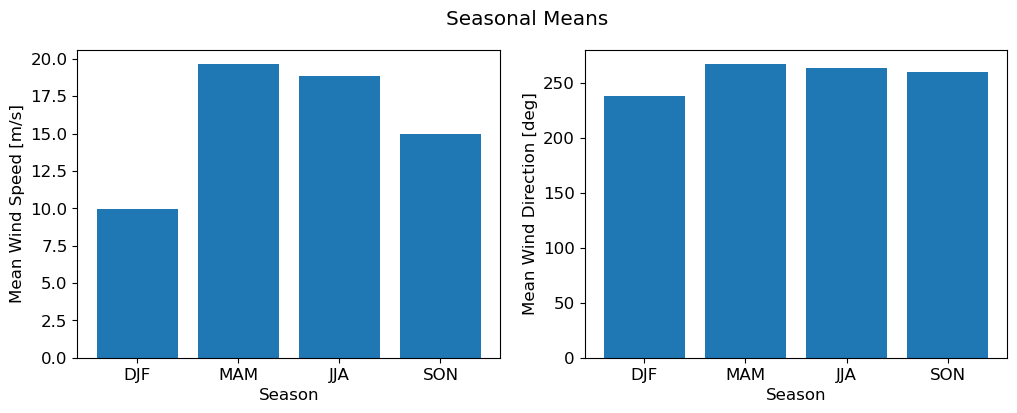

In [24]:
fig = plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.bar(seasonal_mean.season,seasonal_mean.wind_speed)
plt.xlabel('Season')
plt.ylabel('Mean Wind Speed [m/s]')

plt.subplot(1,2,2)
plt.bar(seasonal_mean.season,seasonal_mean.wind_dir)
plt.xlabel('Season')
plt.ylabel('Mean Wind Direction [deg]')

plt.suptitle('Seasonal Means')

# plt.savefig('/Users/mackenzie/Documents/Research/PhD/TNB_Research/Figures/AWS_Manuela/wspd_dir_seasonalmeans.png',
#             dpi=400,
#             bbox_inches='tight',
#             transparent=True)

We group the data seasonally (summer: DJF, fall: MAM, winter: JJA, spring: SON) to further understand the mean wind speed and direction over the fourteen year period (Figure 3). Surprisingly, fall has a slightly greater mean wind speed (~20 m/s) than winter, however, this likely changes when looking at individual years. Mean wind direction is WSW at ~ 250 degrees and this is consistent over fall, winter and spring, with a slightly more southwesterly breeze in summer. 

Text(0.5, 0.98, 'Monthly Means')

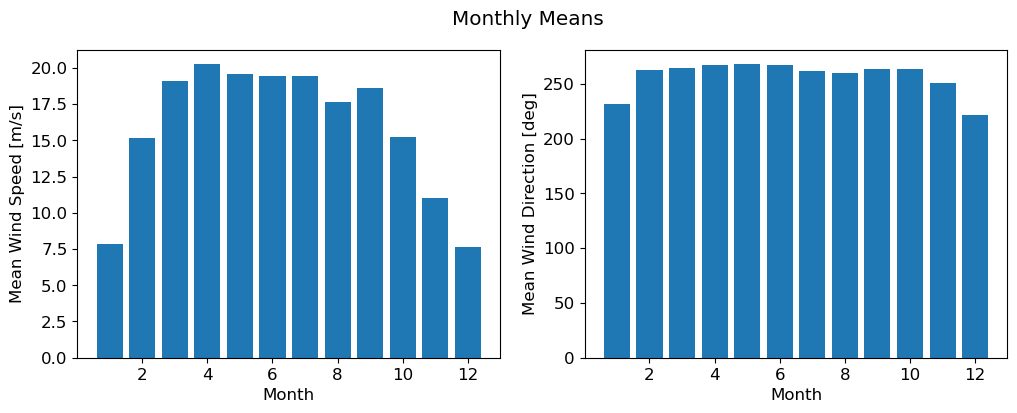

In [16]:
fig = plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.bar(monthly_mean.month,monthly_mean.wind_speed)
plt.xlabel('Month')
plt.ylabel('Mean Wind Speed [m/s]')

plt.subplot(1,2,2)
plt.bar(monthly_mean.month,monthly_mean.wind_dir)
plt.xlabel('Month')
plt.ylabel('Mean Wind Direction [deg]')

plt.suptitle('Monthly Means')

# plt.savefig('/Users/mackenzie/Documents/Research/PhD/TNB_Research/Figures/AWS_Manuela/wspd_dir_monthlymeans.png',
#             dpi=400,
#             bbox_inches='tight',
#             transparent=True)

When grouping the data monthly, we see similar results as the seasonal grouping.

#### Assess interannual variability via anomalies 

In [19]:
# resample the data monthly 
ds_monthly = ds.resample(time='1M').mean()

/opt/anaconda3/envs/TNB/lib/python3.10/site-packages/xarray/core/groupby.py:508: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index_grouper = pd.Grouper(


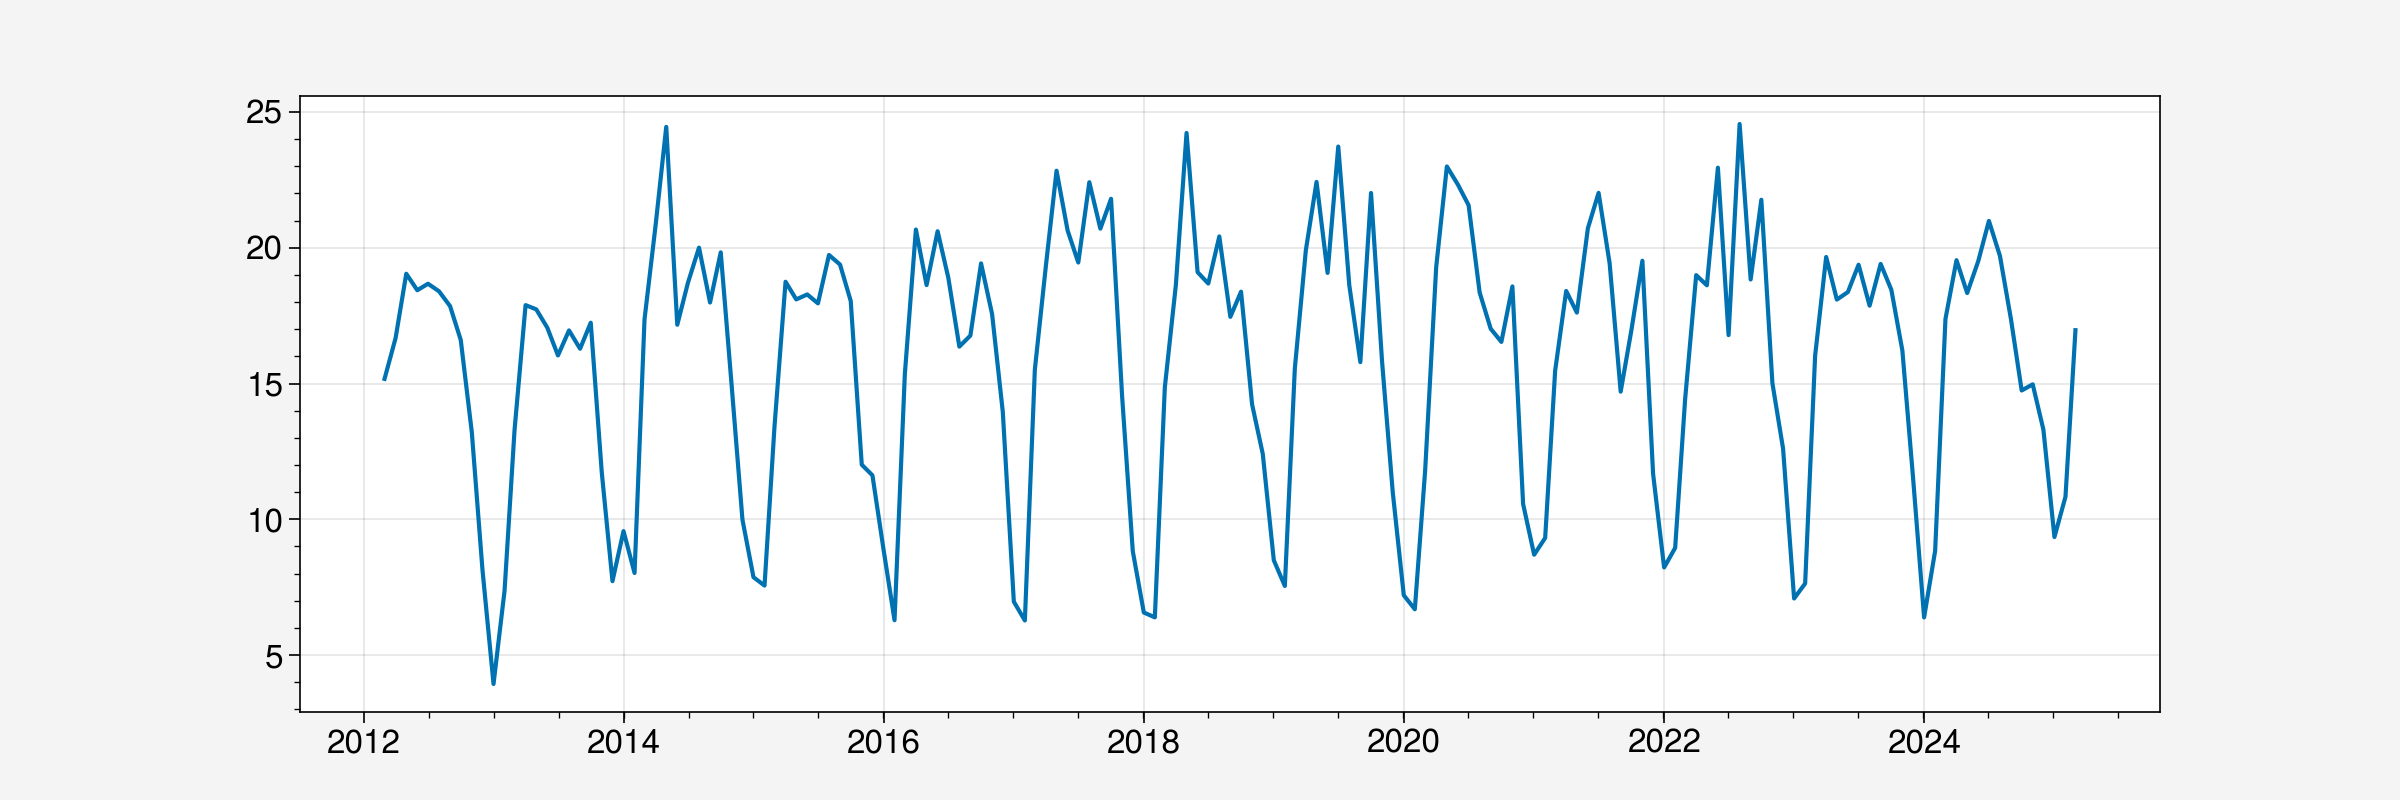

In [20]:
fig = plt.figure(figsize=(12,4))
plt.plot(ds_monthly.time,ds_monthly.wind_speed)

In [21]:
# Step 2: Monthly mean anomalies
monthly_anomalies = ds_monthly.groupby('time.month') - monthly_mean

In [22]:
# calculate yearly anomalies 
yearly_anomalies = (ds.groupby('time.year') - yearly_mean).resample(time='1Y').mean()

/opt/anaconda3/envs/TNB/lib/python3.10/site-packages/xarray/core/groupby.py:508: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  index_grouper = pd.Grouper(


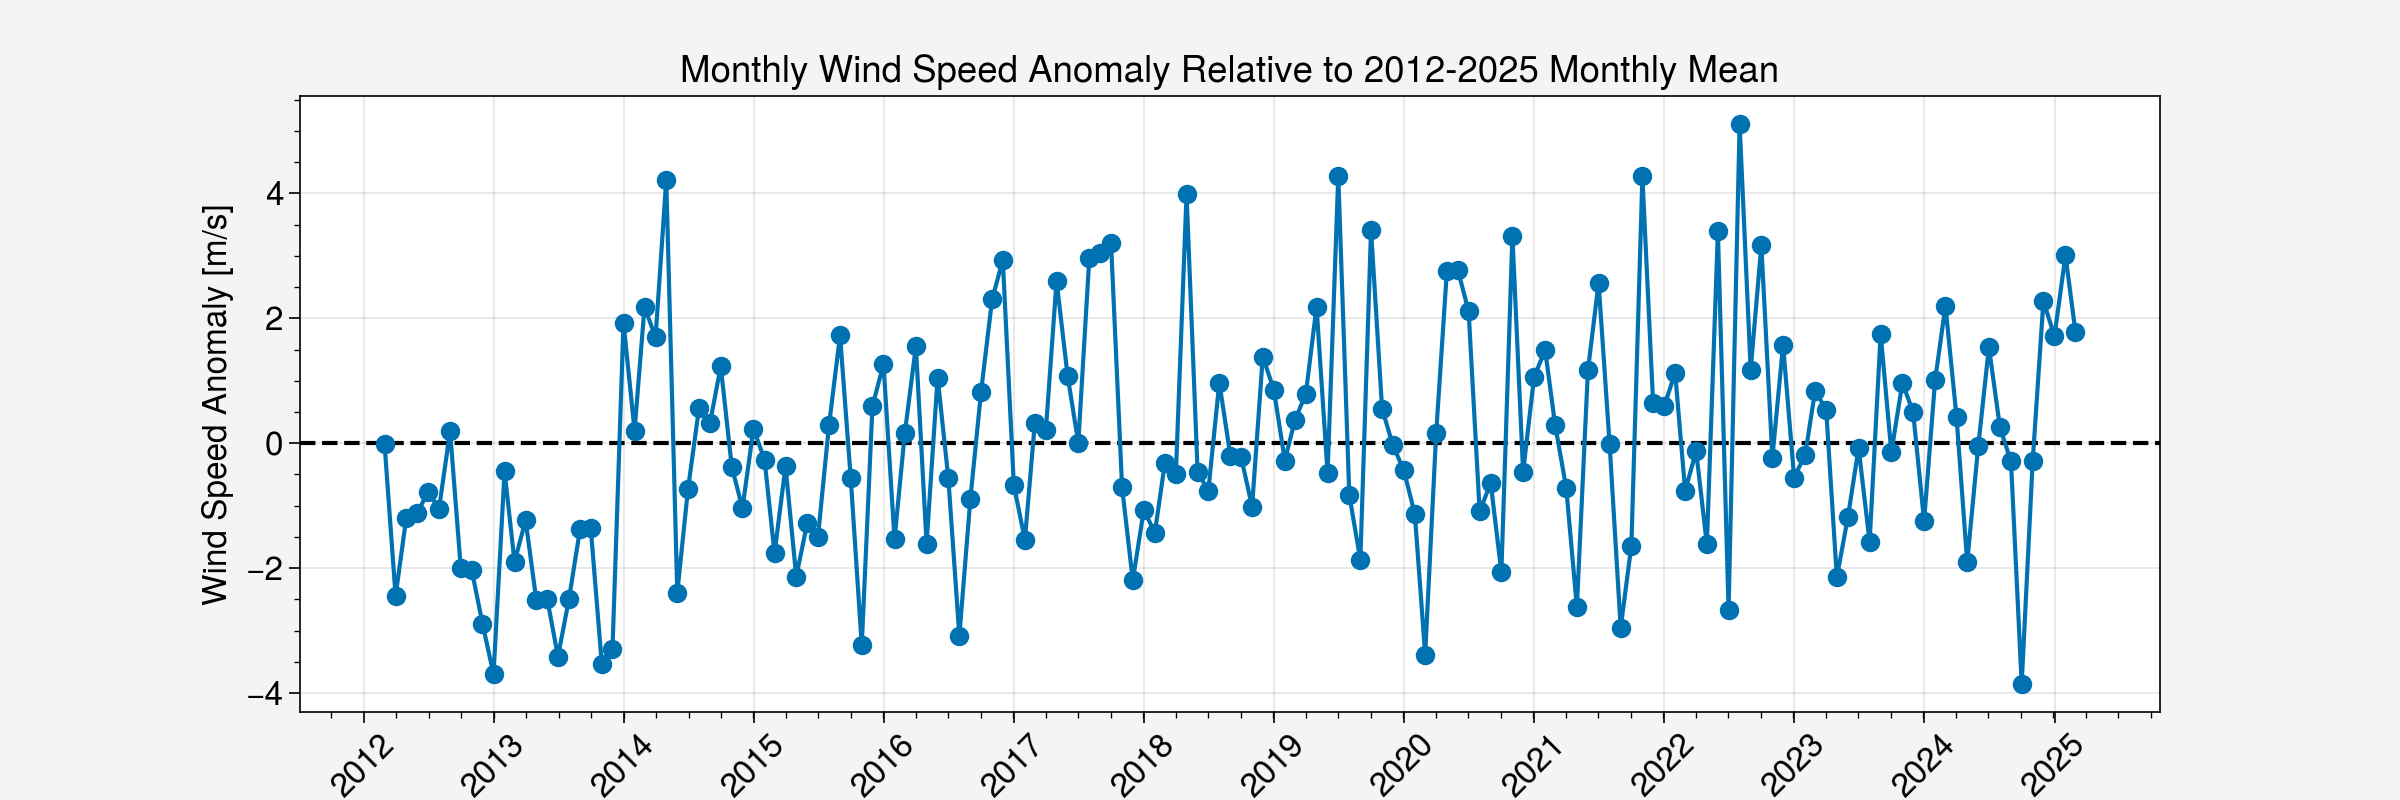

In [23]:
fig = plt.figure(figsize=(12,4))
plt.plot(monthly_anomalies.time,monthly_anomalies.wind_speed,linestyle='-',marker='o')
# Get start and end of x-axis in datetime
x_start, x_end = plt.xlim()
plt.xlim(x_start,x_end)

plt.hlines(y=0,xmin=x_start, xmax=x_end,color='k',linestyle='dashed')
plt.ylabel('Wind Speed Anomaly [m/s]')
plt.xlabel('Time')
plt.title('Monthly Wind Speed Anomaly Relative to 2012-2025 Monthly Mean')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator());
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'));

plt.xticks(rotation=45);

# plt.savefig('/Users/mackenzie/Documents/Research/PhD/TNB_Research/Figures/AWS_Manuela/wspd_monthly_anomaly.png',
#             dpi=400,
#             bbox_inches='tight',
#             transparent=True)

In [37]:
np.timedelta64(364,'D')

numpy.timedelta64(364,'D')

In [38]:
yearly_anomalies.time - np.timedelta64(364,'D')

<xarray.DataArray 'time' (time: 14)>
array(['2012-01-02T00:00:00.000000000', '2013-01-01T00:00:00.000000000',
       '2014-01-01T00:00:00.000000000', '2015-01-01T00:00:00.000000000',
       '2016-01-02T00:00:00.000000000', '2017-01-01T00:00:00.000000000',
       '2018-01-01T00:00:00.000000000', '2019-01-01T00:00:00.000000000',
       '2020-01-02T00:00:00.000000000', '2021-01-01T00:00:00.000000000',
       '2022-01-01T00:00:00.000000000', '2023-01-01T00:00:00.000000000',
       '2024-01-02T00:00:00.000000000', '2025-01-01T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2012-12-31 2013-12-31 ... 2025-12-31

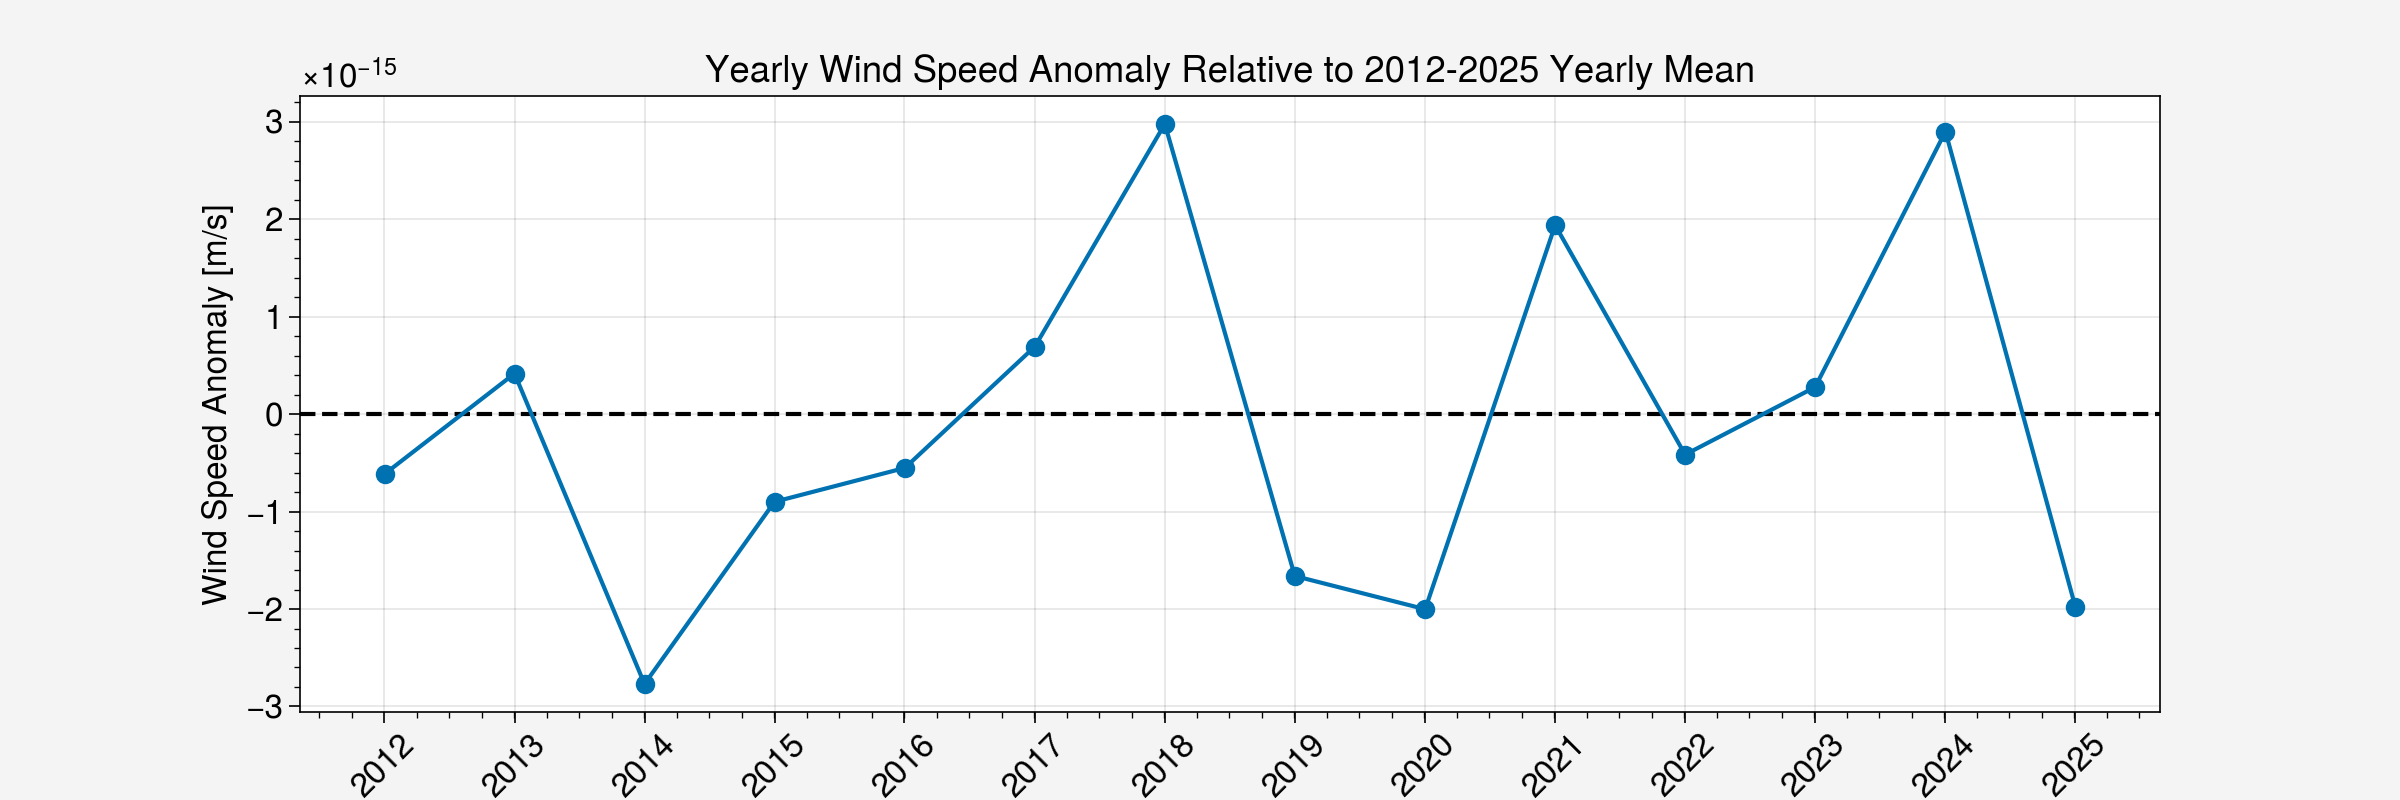

In [40]:
fig = plt.figure(figsize=(12,4))
# subtracting 364 days so datapoints appear at correct year
# yearly_anomalies time has a point at 12-31-YEAR and this makes data look like its part of the next year 
plt.plot((yearly_anomalies.time- np.timedelta64(364,'D')),yearly_anomalies.wind_speed,linestyle='-',marker='o')
# Get start and end of x-axis in datetime
x_start, x_end = plt.xlim()
plt.xlim(x_start,x_end)

plt.hlines(y=0,xmin=x_start, xmax=x_end,color='k',linestyle='dashed')
plt.ylabel('Wind Speed Anomaly [m/s]')
plt.xlabel('Time')
plt.title('Yearly Wind Speed Anomaly Relative to 2012-2025 Yearly Mean')

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator());
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'));

plt.xticks(rotation=45);

We can see interannual variability in yearly mean wind speed ranges from approximately +/- 3 m/s relative to the 2012-2025 yearly mean. 2018 has the record for the most anomalously high year, and 2014 for anomalously low. 

### Investigate katabatic winds 
First investigate katabatic winds by using a defining threshold of 25 m/s. Data is kept at the 10 minute output and a "katabatic event" is not defined yet 

In [41]:
# define threshold for katabatic wind speed and create a mask
katabatic = ds.wind_speed > 25

In [42]:
# fraction of time 
freq = katabatic.resample(time='1M').mean()  # gives fraction of time per month
# count of katabatic winds per month 
count = katabatic.resample(time='1M').sum()


/opt/anaconda3/envs/TNB/lib/python3.10/site-packages/xarray/core/groupby.py:508: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index_grouper = pd.Grouper(
/opt/anaconda3/envs/TNB/lib/python3.10/site-packages/xarray/core/groupby.py:508: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index_grouper = pd.Grouper(


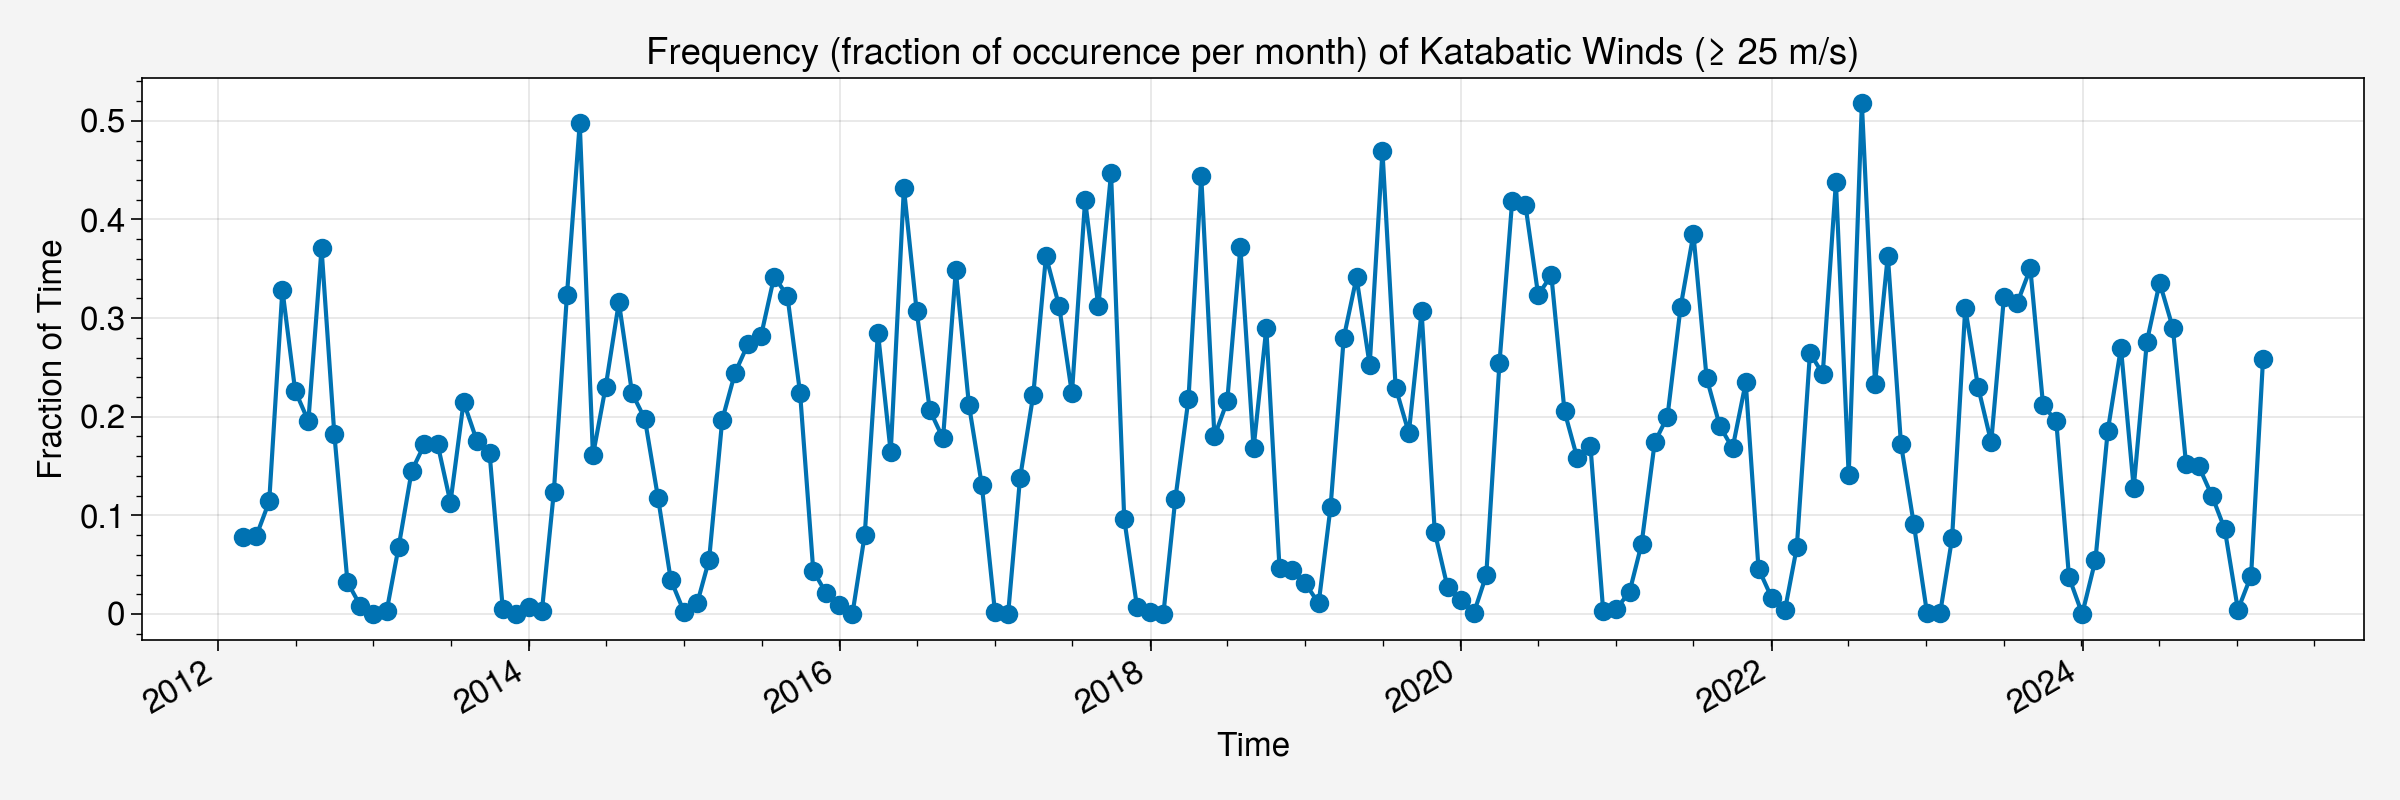

In [43]:
import matplotlib.pyplot as plt

freq.plot(marker='o',linestyle='-',figsize=(12,4))
plt.title("Frequency (fraction of occurence per month) of Katabatic Winds (≥ 25 m/s)")
plt.ylabel("Fraction of Time")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()


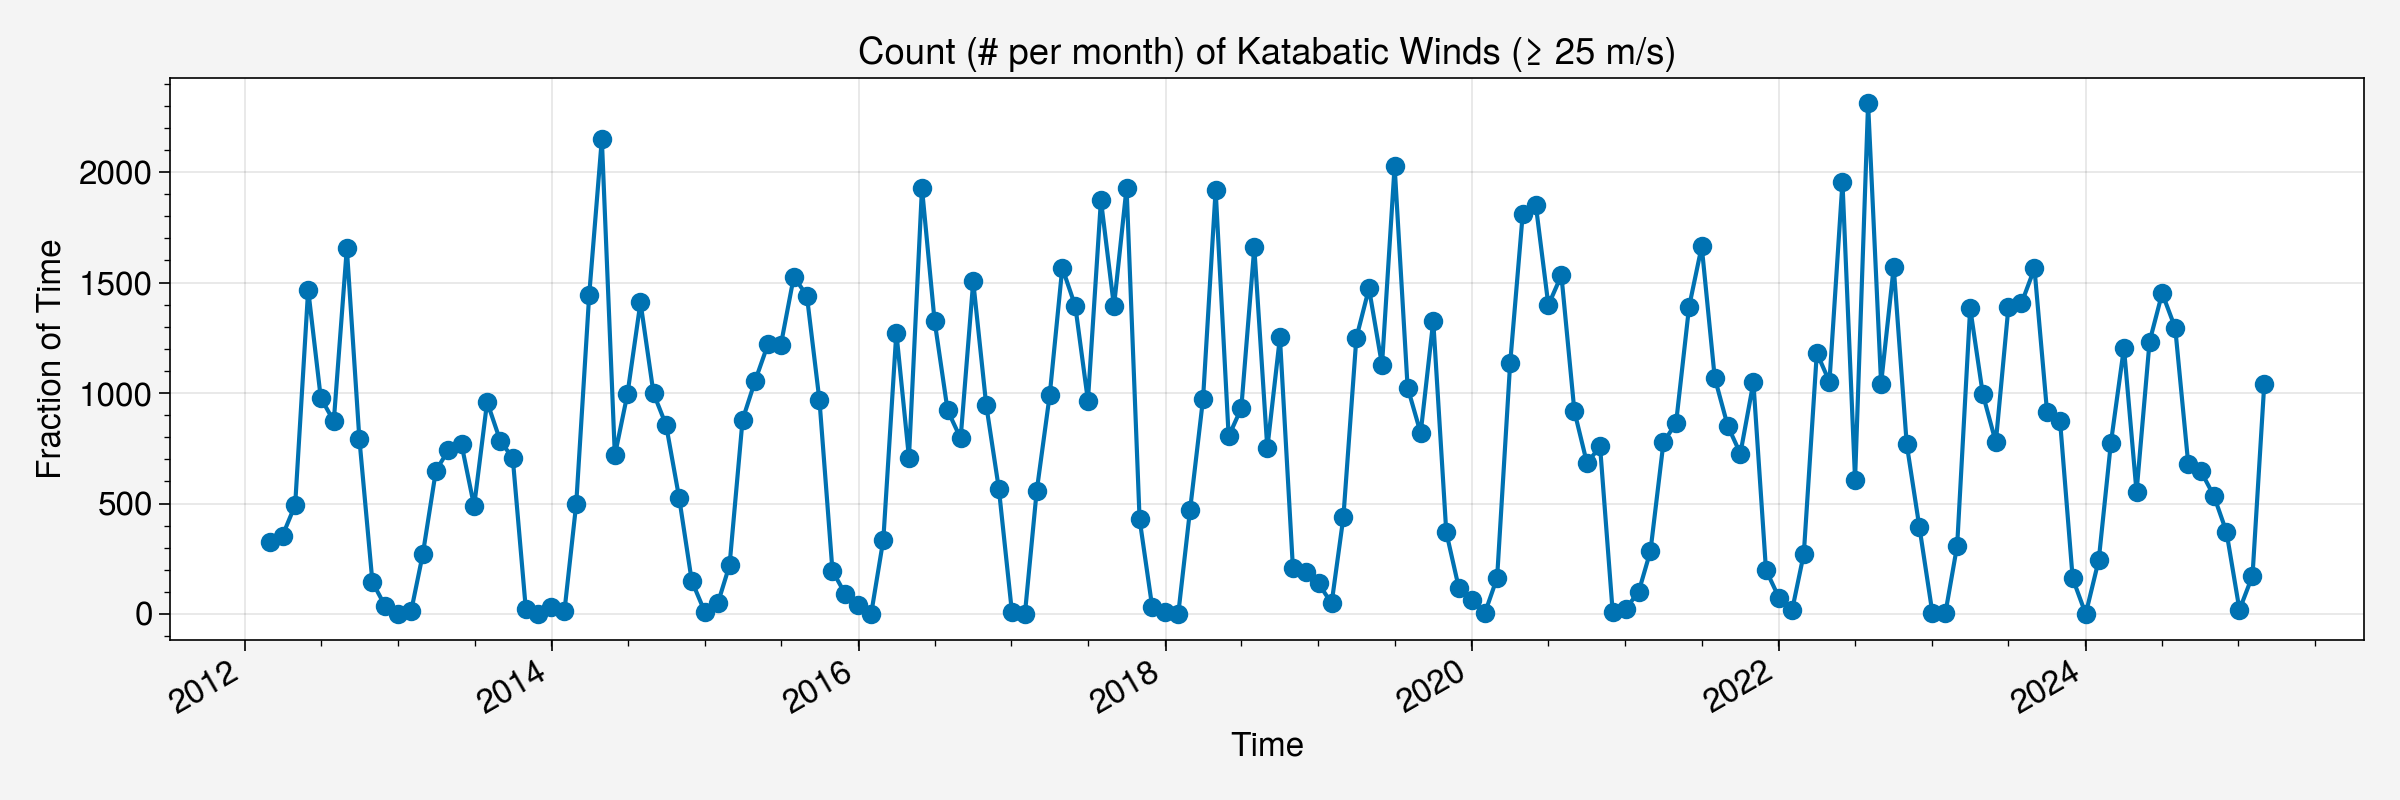

In [44]:
count.plot(marker='o',linestyle='-',figsize=(12,4))
plt.title("Count (# per month) of Katabatic Winds (≥ 25 m/s)")
plt.ylabel("Fraction of Time")
plt.xlabel("Time")
plt.grid(True)
plt.tight_layout()
plt.show()

The above two plots show the frequency and occurance of katabatic wind speeds on a monthly basis. A seasonal cycle is evident, with katabatic wind occurance increasing in fall / winter months and decreasing to almost zero in summer months. 

In [45]:
# make a monthly decadal count for the 2012-2025 period 
katabatic_count_decadal = count.groupby('time.month').sum()

Text(0, 0.5, 'Katabatic Wind Count')

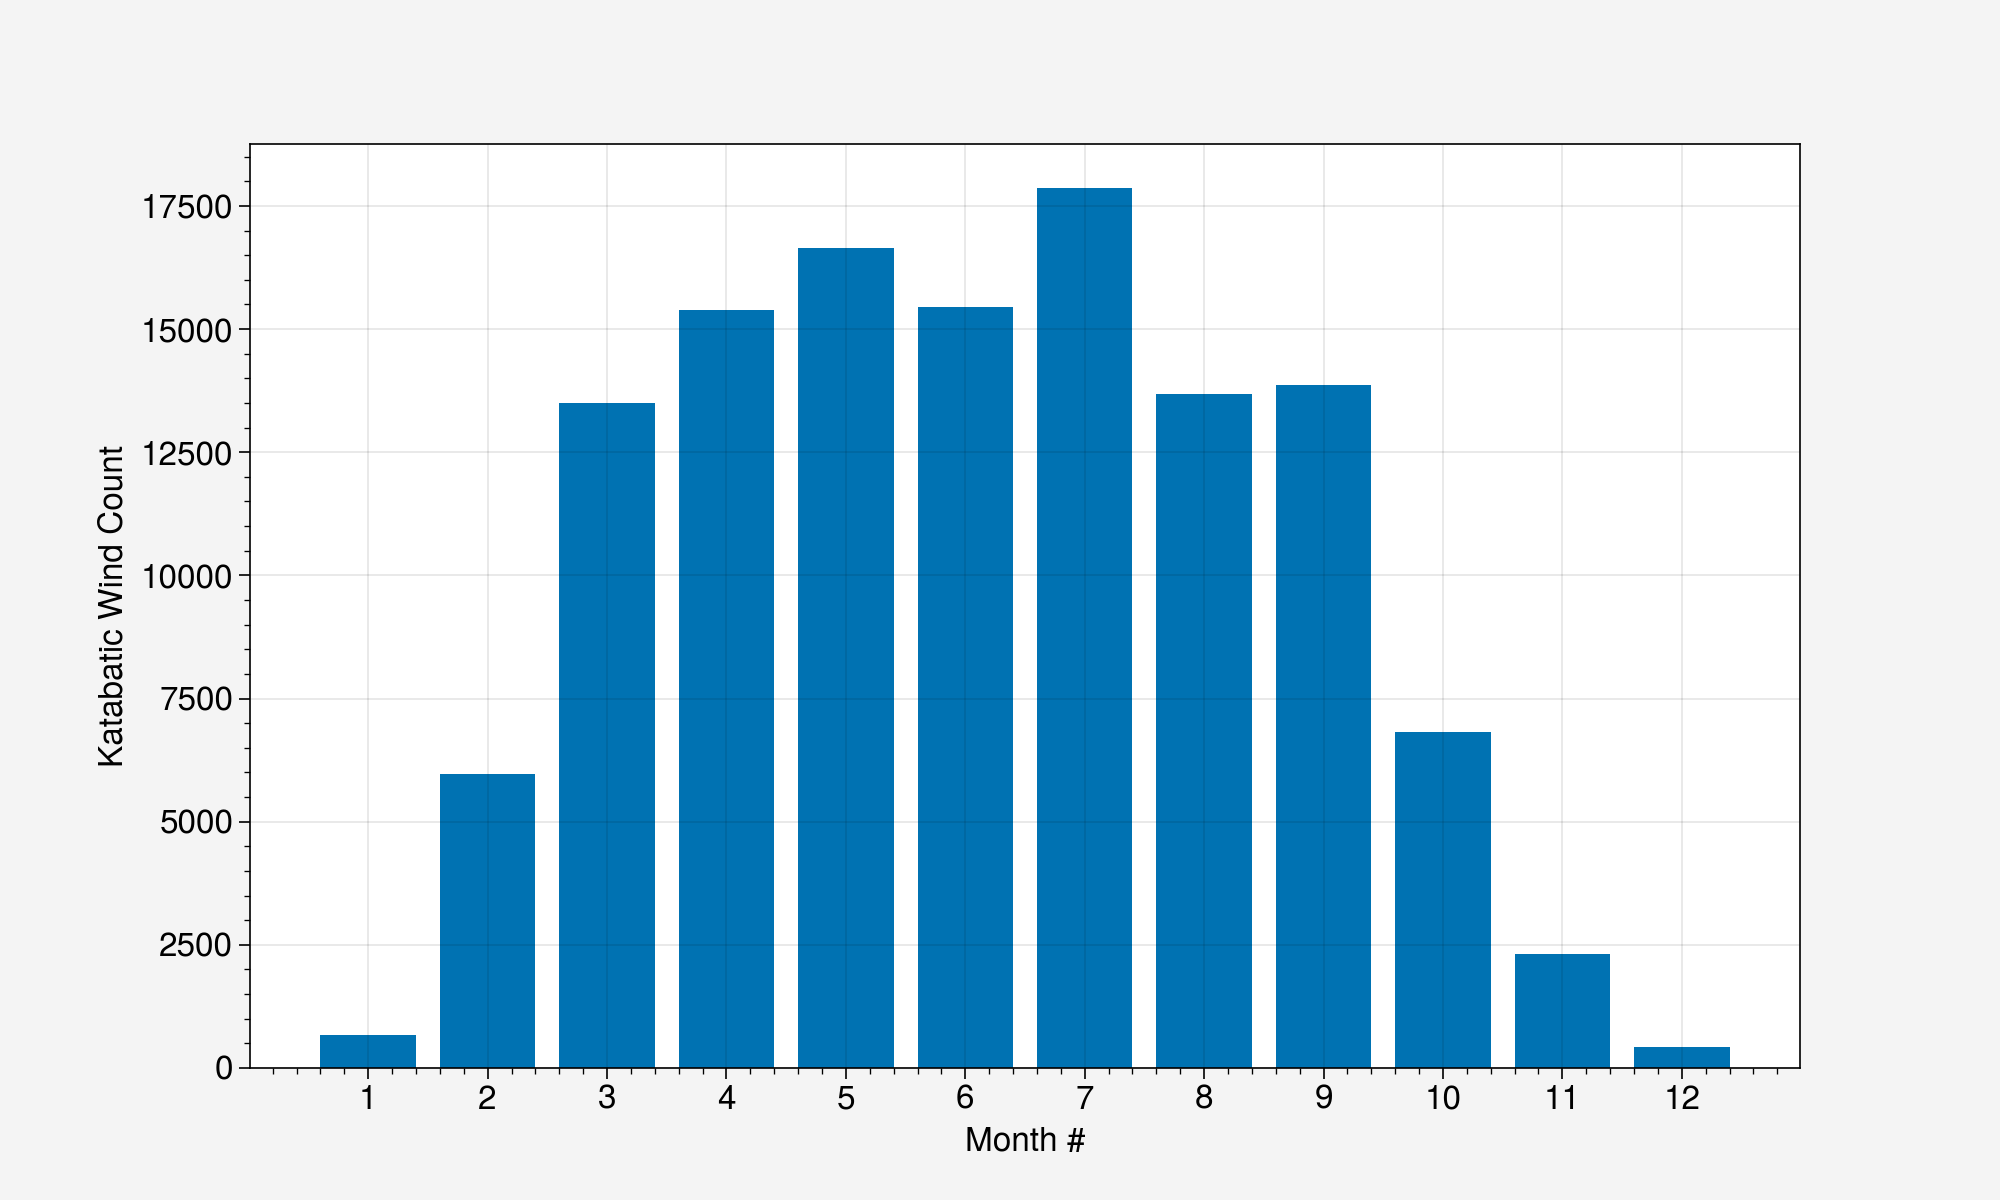

In [46]:
fig = plt.figure(figsize=(10,6))
plt.bar(katabatic_count_decadal.month,katabatic_count_decadal)
plt.xticks(np.arange(1,13,1));
plt.xlabel('Month #')
plt.ylabel('Katabatic Wind Count')

We can see that July has the highest occurance of katabatic winds from the years 2012-2025 

In [47]:
# calculate katabatic count anomaly 
katabatic_count_anomaly = katabatic.resample(time='1M').sum().groupby('time.month') - count.groupby('time.month').mean()

/opt/anaconda3/envs/TNB/lib/python3.10/site-packages/xarray/core/groupby.py:508: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  index_grouper = pd.Grouper(


Text(0, 0.5, 'Katabatic Count Monthly Anomaly')

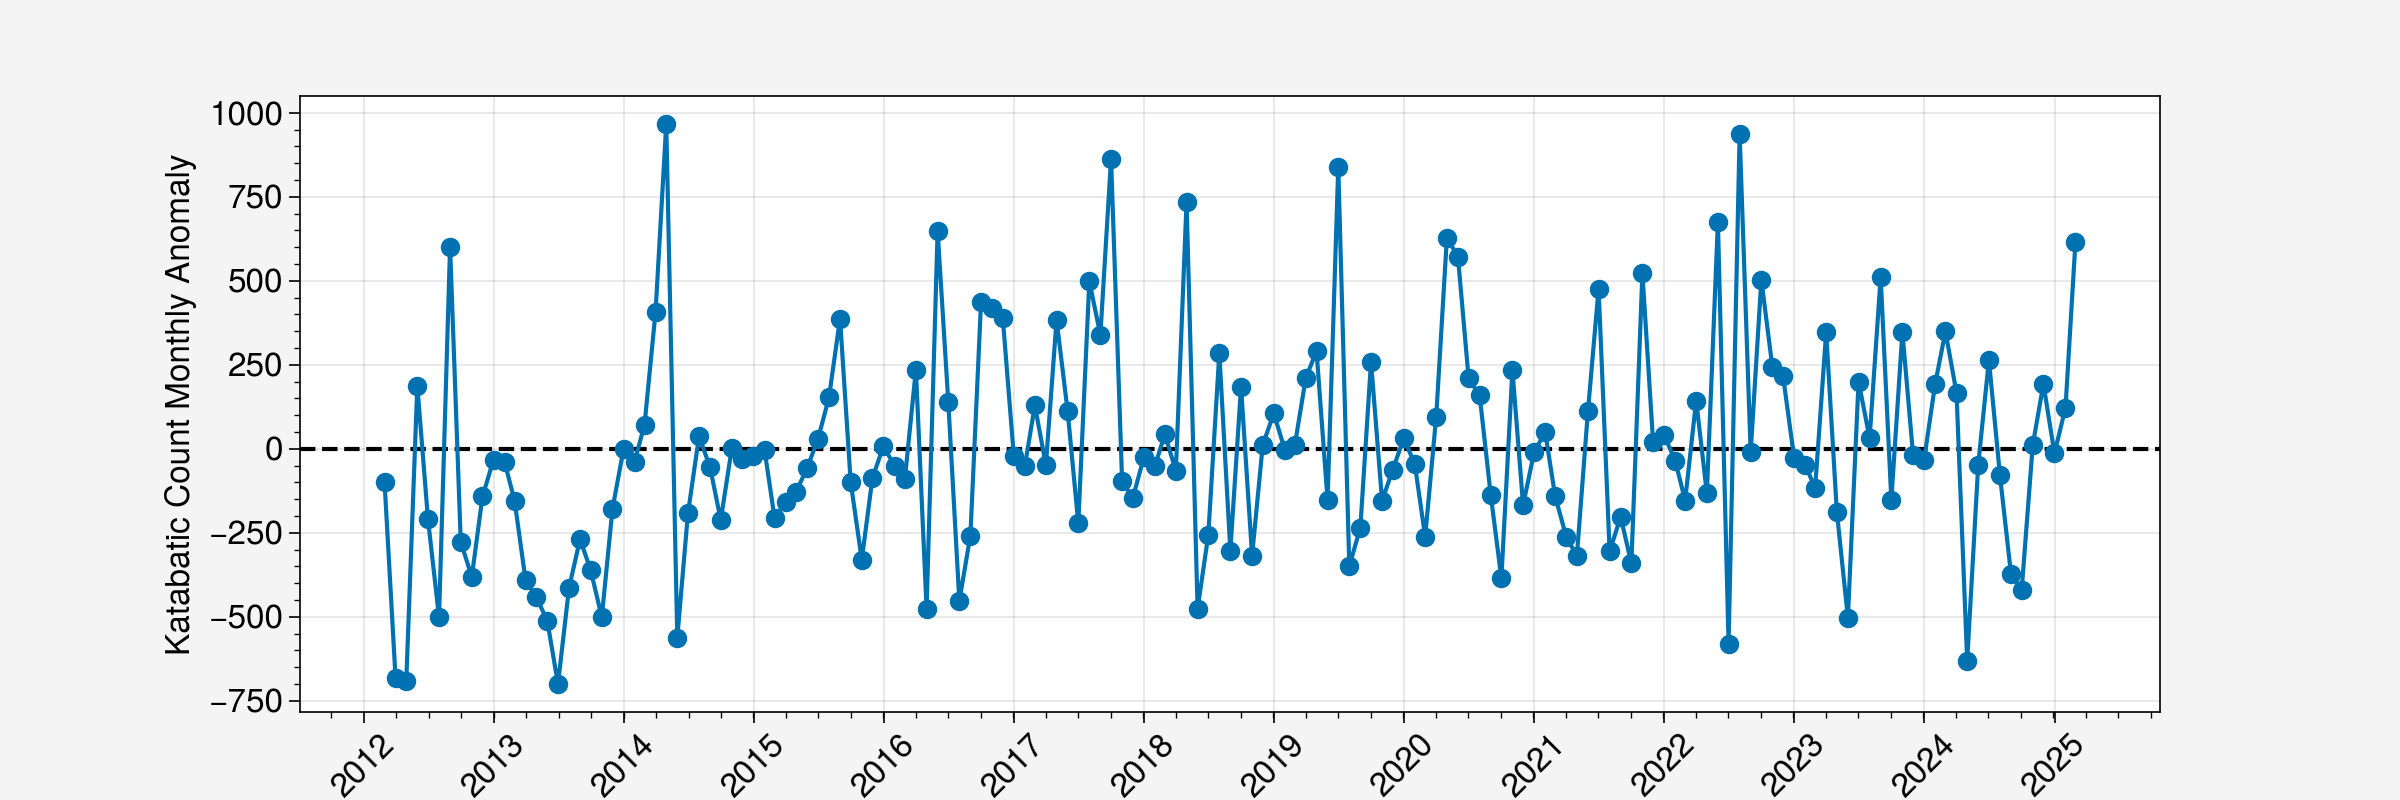

In [50]:
fig = plt.figure(figsize=(12,4))
plt.plot(katabatic_count_anomaly.time,katabatic_count_anomaly,linestyle='-',marker='o')
# Get start and end of x-axis in datetime
x_start, x_end = plt.xlim()
plt.xlim(x_start,x_end)

plt.hlines(y=0,xmin=x_start, xmax=x_end,color='k',linestyle='dashed')
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator());
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'));

plt.xticks(rotation=45);

plt.ylabel('Katabatic Count Monthly Anomaly')


### Define Katabatic Events 

We are intersted in katabatic wind events that trigger a polynya opening / sea ice production / HSSW production. We define a katabatic wind event as one where winds speed are equal to or greater than 25 m/s for at least one hour. 

In [51]:
import xarray as xr
import numpy as np
from scipy.ndimage import label

def extract_katabatic_segments(wind, threshold=25, min_duration=6):
    """
    Return a single DataArray with katabatic wind events labeled by 'event',
    retaining the time coordinate for filtering.
    """

    # define mask based on wind speed threshold 
    mask = wind >= threshold
    labeled, num_labels = label(mask.values)

    # initiate empty lists
    event_list = []
    time_list = []
    event_id_list = []

    # loop through numbered labels to create mask 
    for label_id in range(1, num_labels + 1):
        region_mask = (labeled == label_id)
    # identify if region mask sums up to 6 (i.e. 1 hour: 6 x 10 minute timestep)
        # if yes, create a data array segment based on region mask and append to empty lists 
        if region_mask.sum() >= min_duration:
            region_mask_da = xr.DataArray(region_mask, coords={"time": wind.time}, dims="time")
            segment = wind.where(region_mask_da, drop=True)
            
            event_list.append(segment.values)
            time_list.append(segment.time.values)
            event_id_list.append(np.full(segment.time.shape, label_id))

    if not event_list:
        return None

    # Flatten all event time series into one
    all_values = np.concatenate(event_list)
    all_times = np.concatenate(time_list)
    all_events = np.concatenate(event_id_list)

    # Create final DataArray with 'time' and 'event' as coordinates
    katabatic = xr.DataArray(
        all_values,
        coords={
            "time": all_times,
            "event": ("time", all_events)
        },
        dims="time",
        name="katabatic_wind"
    )

    return katabatic


In [52]:
# apply function to wind speed data to create katabatic events 
segments = extract_katabatic_segments(wind=ds.wind_speed)

In [53]:
segments 

<xarray.DataArray 'katabatic_wind' (time: 111019)>
array([25. , 25.4, 26.3, ..., 27.8, 27.7, 25.2])
Coordinates:
  * time     (time) datetime64[ns] 2012-02-08T11:20:00 ... 2025-02-26T22:50:00
    event    (time) int64 1 1 1 1 1 1 1 4 ... 9908 9908 9908 9908 9908 9908 9908

In [54]:
# seperate the katabatic events into seasons based on numbered months 
summer_segments = segments.loc[segments['time.month'].isin([12,1,2])]
fall_segments = segments.loc[segments['time.month'].isin([3,4,5])]
winter_segments = segments.loc[segments['time.month'].isin([6,7,8])]
spring_segments = segments.loc[segments['time.month'].isin([9,10,11])]

Text(0.5, 1.0, 'Spring')

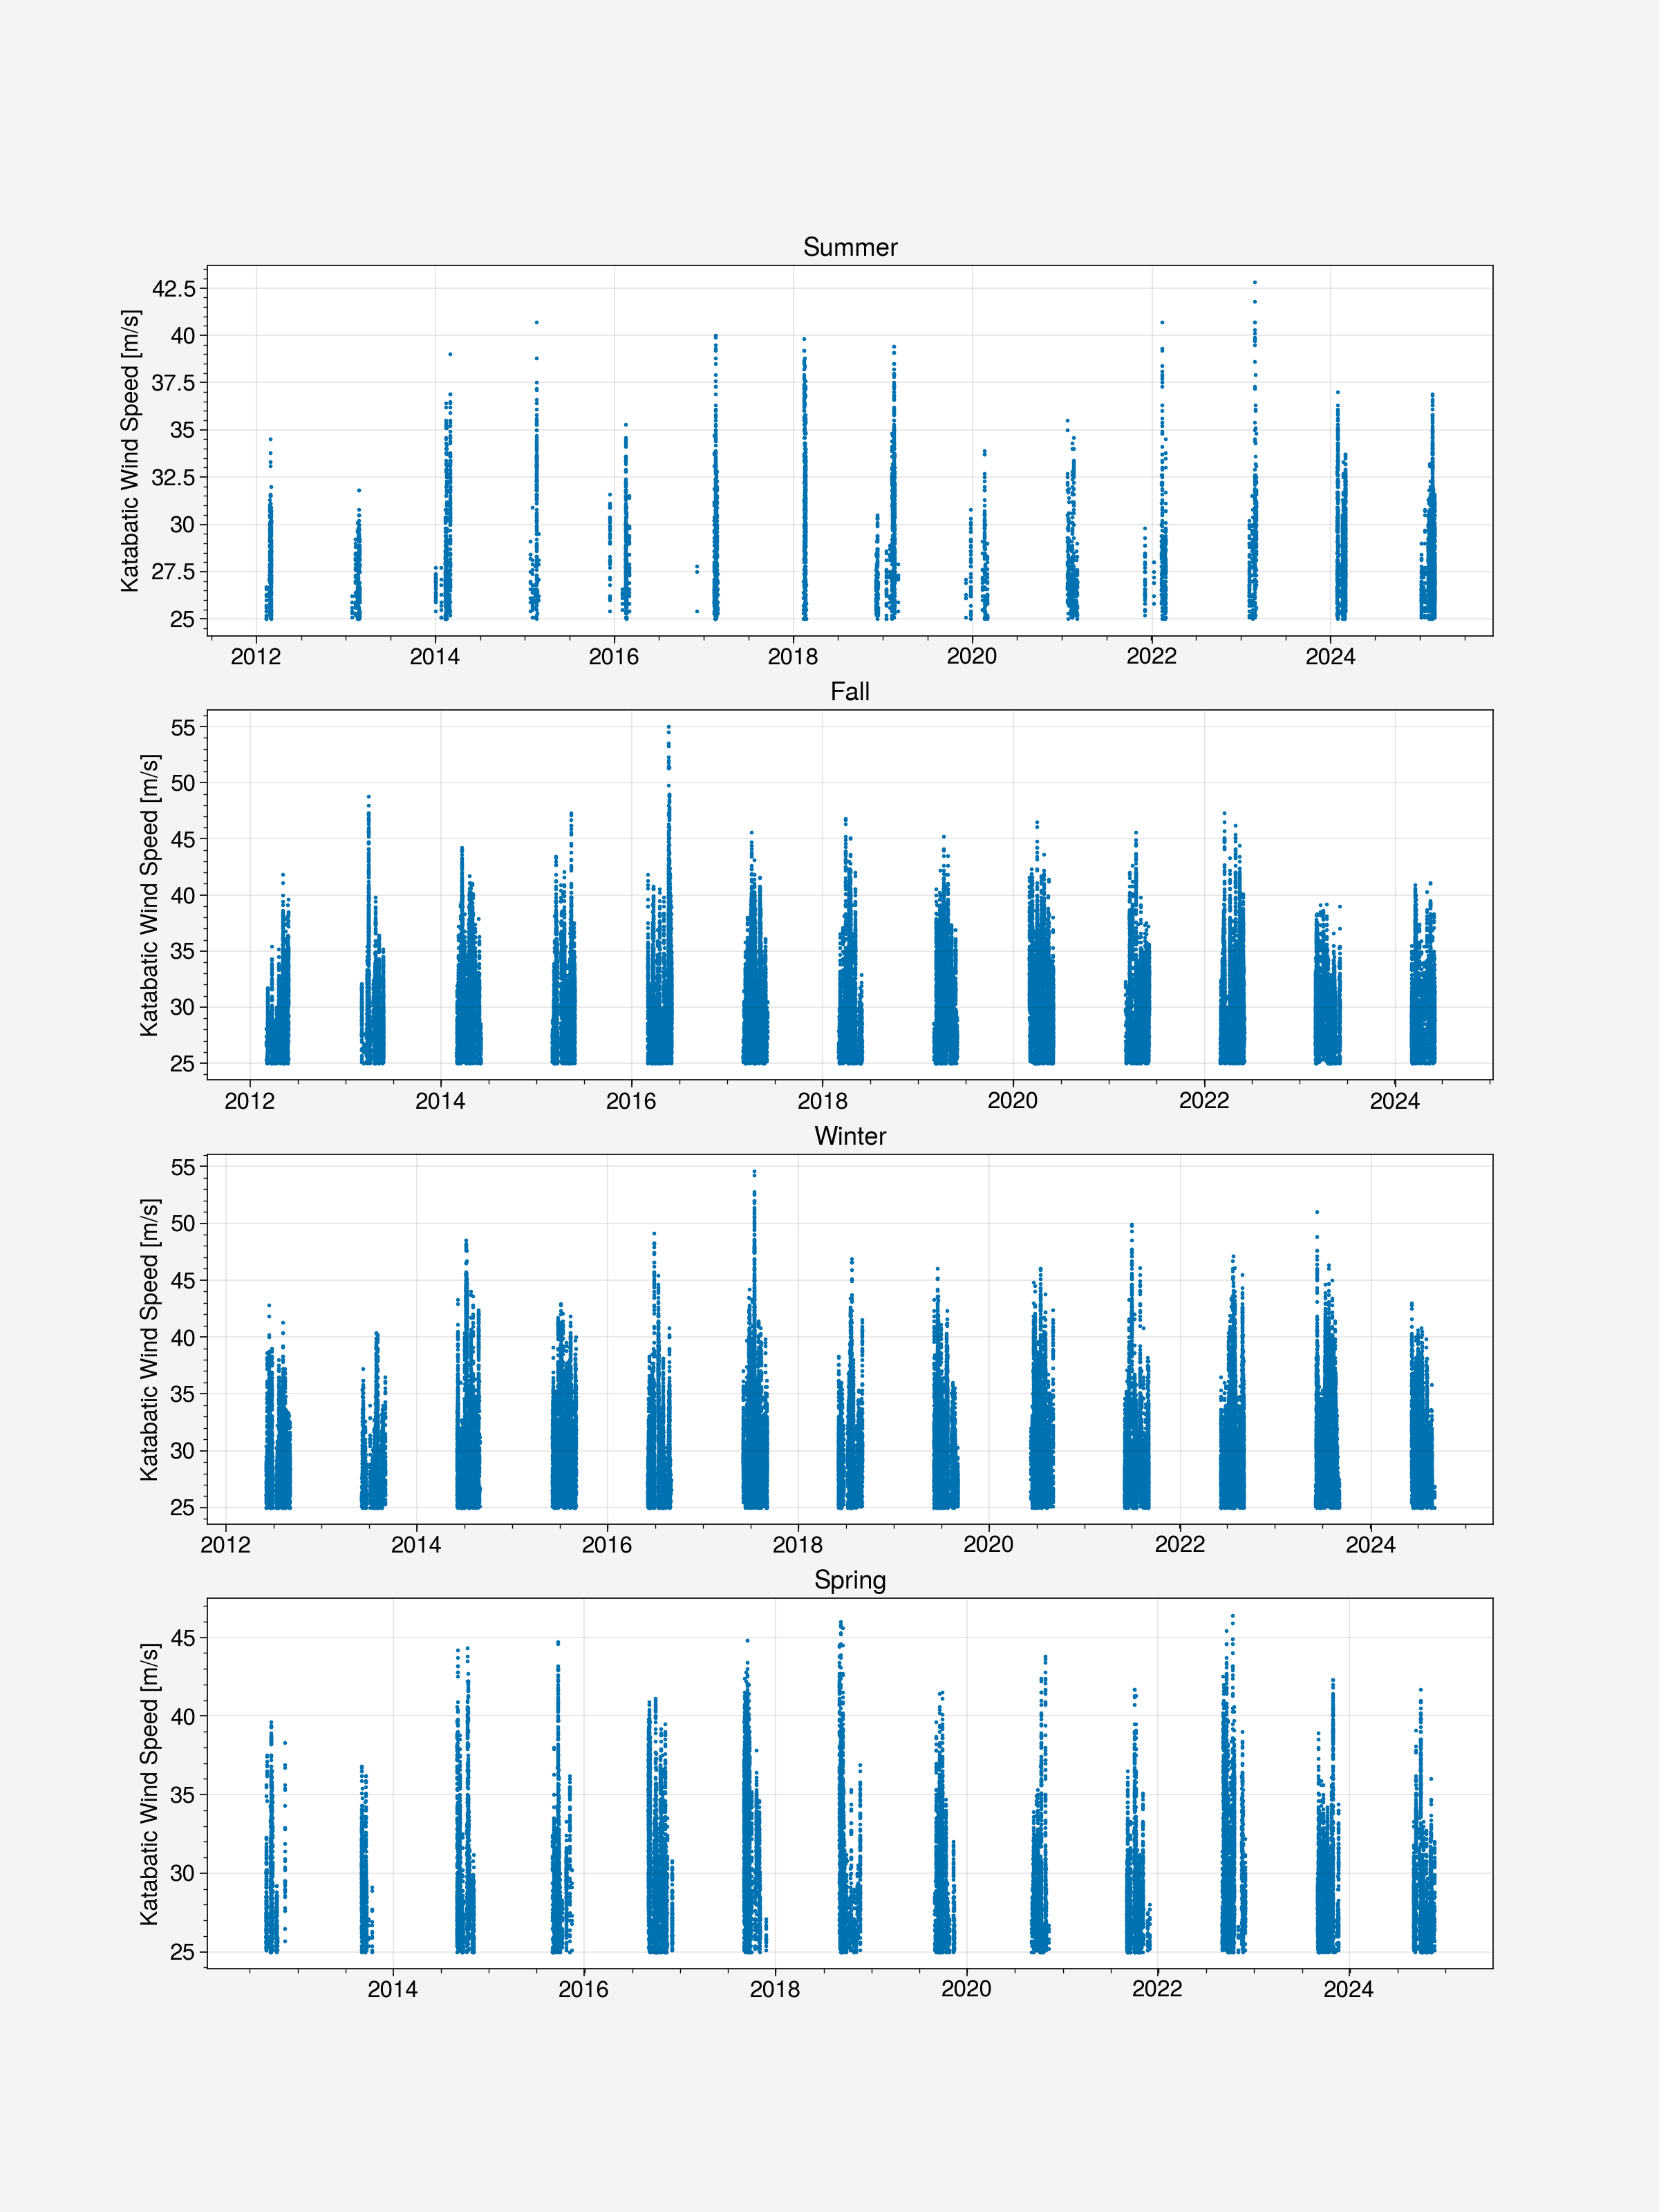

In [55]:
# plot katabatic wind events by season 
fig = plt.figure(figsize=(12,16))
plt.subplot(4,1,1)
plt.scatter(summer_segments.time,summer_segments,s=2)
plt.ylabel('Katabatic Wind Speed [m/s]')
plt.title('Summer')


plt.subplot(4,1,2)
plt.scatter(fall_segments.time,fall_segments,s=2)
plt.ylabel('Katabatic Wind Speed [m/s]')
plt.title('Fall')

plt.subplot(4,1,3)
plt.scatter(winter_segments.time,winter_segments,s=2)
plt.ylabel('Katabatic Wind Speed [m/s]')
plt.title('Winter')

plt.subplot(4,1,4)
plt.scatter(spring_segments.time,spring_segments,s=2)
plt.ylabel('Katabatic Wind Speed [m/s]')
plt.title('Spring')

In [56]:
# calculate seasonal counts of katabatic wind events 
# for loop to get useful info per year

winter_count = [] 
years = np.arange(2012,2026,1)
for i in range(len(years)):
    # select year 
    if i == range(len(years))[-1]:
        winter_count.append(np.nan)
    else:
        subset = winter_segments.sel(time=str(years[i]))
        winter_count.append(len(np.unique(subset.event)))

spring_count = [] 
years = np.arange(2012,2026,1)
for i in range(len(years)):
    # select year 
    if i == range(len(years))[-1]:
        spring_count.append(np.nan)
    else:
        subset = spring_segments.sel(time=str(years[i]))
        spring_count.append(len(np.unique(subset.event)))

fall_count = [] 
years = np.arange(2012,2026,1)
for i in range(len(years)):
    # select year 
    if i == range(len(years))[-1]:
        fall_count.append(np.nan)
    else:
        subset = fall_segments.sel(time=str(years[i]))
        fall_count.append(len(np.unique(subset.event)))

In [57]:
fall_count

[62, 53, 82, 73, 78, 83, 100, 84, 96, 82, 89, 91, 70, nan]

In [58]:
winter_count

[105, 77, 80, 104, 82, 106, 114, 80, 95, 121, 109, 100, 93, nan]

In [59]:
spring_count

[27, 24, 48, 36, 78, 50, 50, 54, 46, 82, 62, 46, 53, nan]

In [60]:
summer_count = [] 
years = np.arange(2012,2026,1)
for i in range(len(years)):
    # select year 
    if i == 0: 
        subset = summer_segments.sel(time=str(years[i]))
        summer_count.append(len(np.unique(subset.event)))

    elif i == range(len(years))[-1]:
        subset = summer_segments.sel(time=str(years[i]))
        summer_count.append(len(np.unique(subset.event)))
    else:
        year = summer_segments.loc[summer_segments['time.year'].isin(years[i])]
        dec_contribution = len(np.unique(year.loc[year['time.month'].isin([12])].event))

        year = summer_segments.loc[summer_segments['time.year'].isin(years[i+1])]
        feb_jan_contribution = len(np.unique(year.loc[year['time.month'].isin([1,2])].event))

        summer_count.append(np.sum([dec_contribution,feb_jan_contribution]))

In [61]:
summer_count

[16, 22, 8, 9, 19, 10, 14, 11, 19, 14, 8, 27, 35, 35]

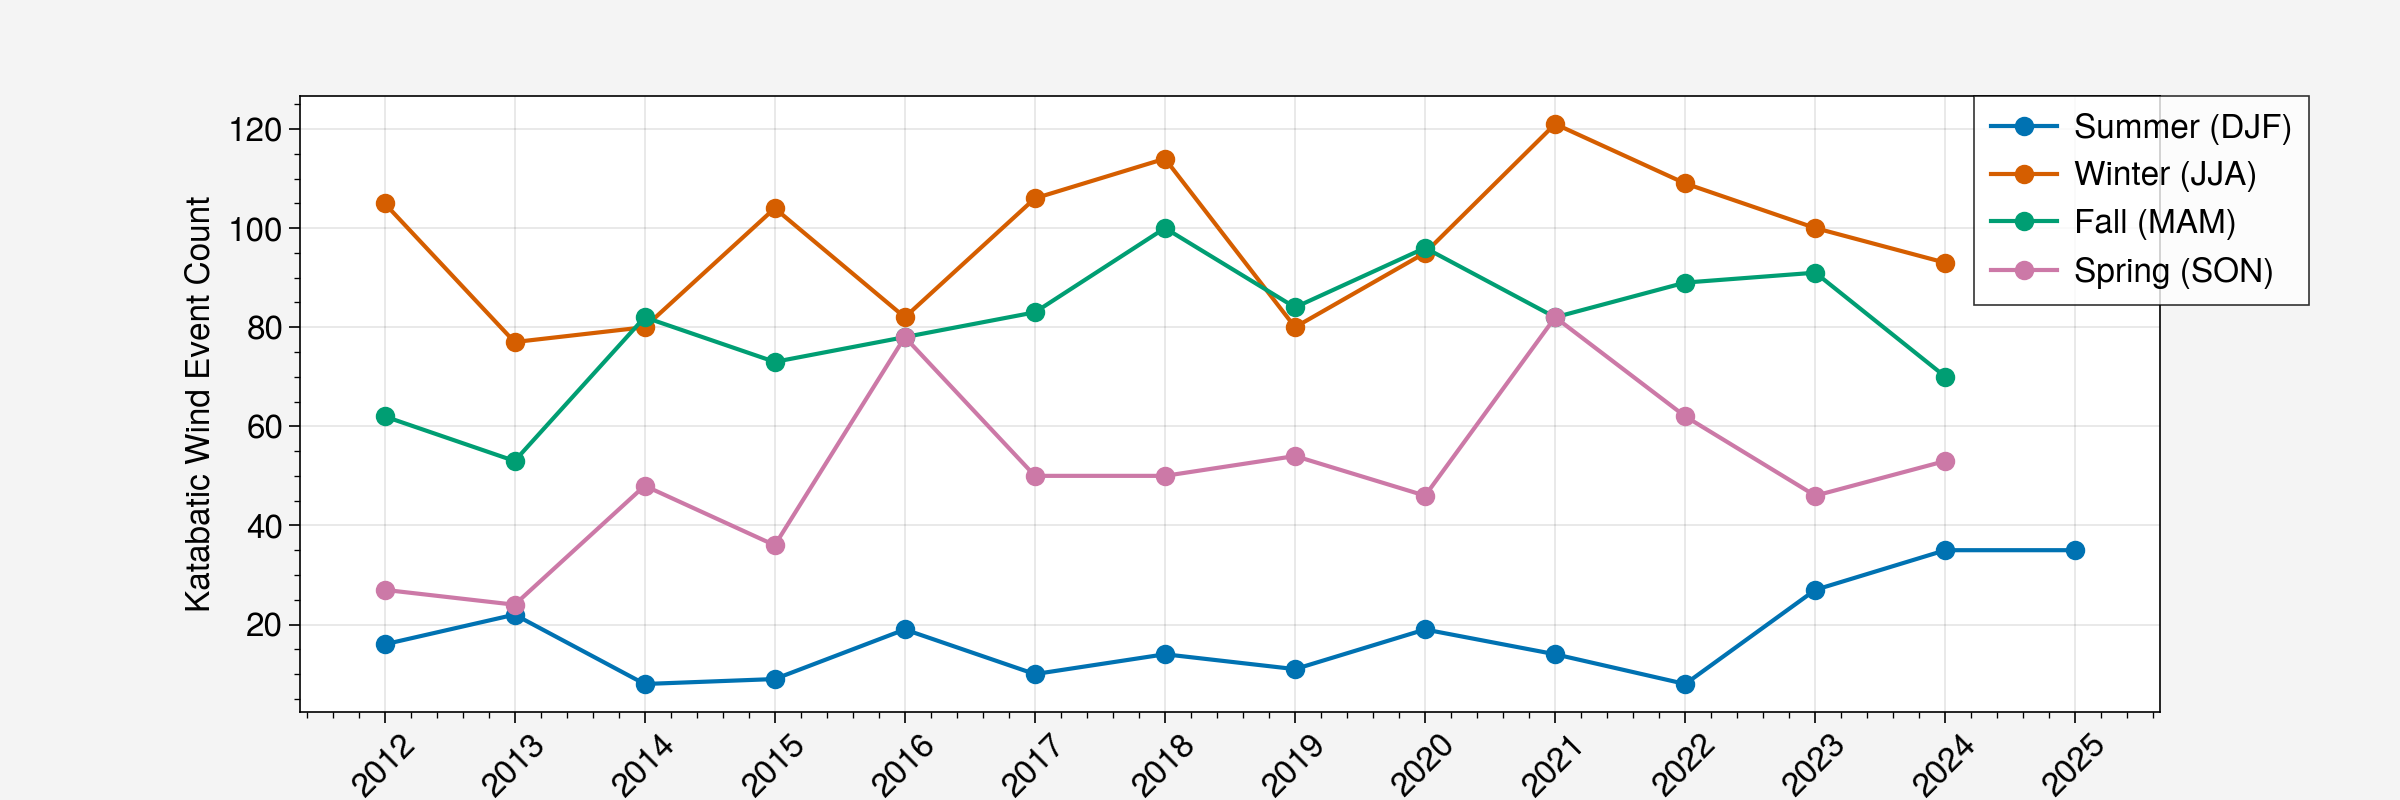

In [62]:
# plot katabatic wind event count per season 
fig = plt.figure(figsize=(12,4))
plt.plot(years,summer_count,label='Summer (DJF)',linestyle='-',marker='o')
plt.plot(years,winter_count, label='Winter (JJA)',linestyle='-',marker='o')
plt.plot(years,fall_count, label='Fall (MAM)',linestyle='-',marker='o')
plt.plot(years,spring_count,label='Spring (SON)',linestyle='-',marker='o')
plt.xticks(years,rotation=45);
plt.ylabel('Katabatic Wind Event Count')
plt.legend(bbox_to_anchor=(0.9, 1), loc='upper left')

# plt.savefig('/Users/mackenzie/Documents/Research/PhD/TNB_Research/Figures/AWS_Manuela/katabatic_count_seasonal.png',
#             dpi=400,
#             bbox_inches='tight',
#             transparent=True)

Important to note here that summer does indeed have katabatic wind events. I should look into whether these events actually produce any HSSW - would need to figure out if any ice is produced during these summer events. Perhaps during early summer before the polynya is completely open. 

In [63]:
# how many katabatic wind events for each year? 
# average duration of each katabatic wind event per year?
# max duration of katabatic wind event per year? 
# mean wind speed in katabatic events per year? 
# max wind speed in katabatic events per year? 
# what month has the most katabatic wind events per year? 

# initiate empty lists 
events_per_year = [] 
mean_event_duration = []
max_event_duration = []
mean_wind_speed = []
max_wind_speed = []
years = np.arange(2012,2026,1)

# for loop to get useful info per year
for i in range(len(years)):
    # select year 
    subset = segments.sel(time=str(years[i]))
    # mean wind speed per year 
    mean_wind_speed.append(subset.mean().values)
    # max wind speed per year 
    max_wind_speed.append(subset.max().values)
    # number of katabatic wind events per year 
    events_per_year.append(len(np.unique(subset.event)))
    # initiate empty list 
    event_duration = []
    # loop through individual events in one year 
    for i in range(len(np.unique(subset.event))):
        # select one event 
        event = subset.where(subset.event == np.unique(subset.event)[i],drop=True)
        # calculate event duration and add to list 
        event_duration.append(np.sum(np.diff(event.time))/np.timedelta64(1, 'h'))   # convert ns to hours
    # mean event duration per year 
    mean_event_duration.append(np.mean(event_duration))
    # max event duration per year 
    max_event_duration.append(np.max(event_duration))
    

Text(0, 0.5, 'Max Event Duration [hrs]')

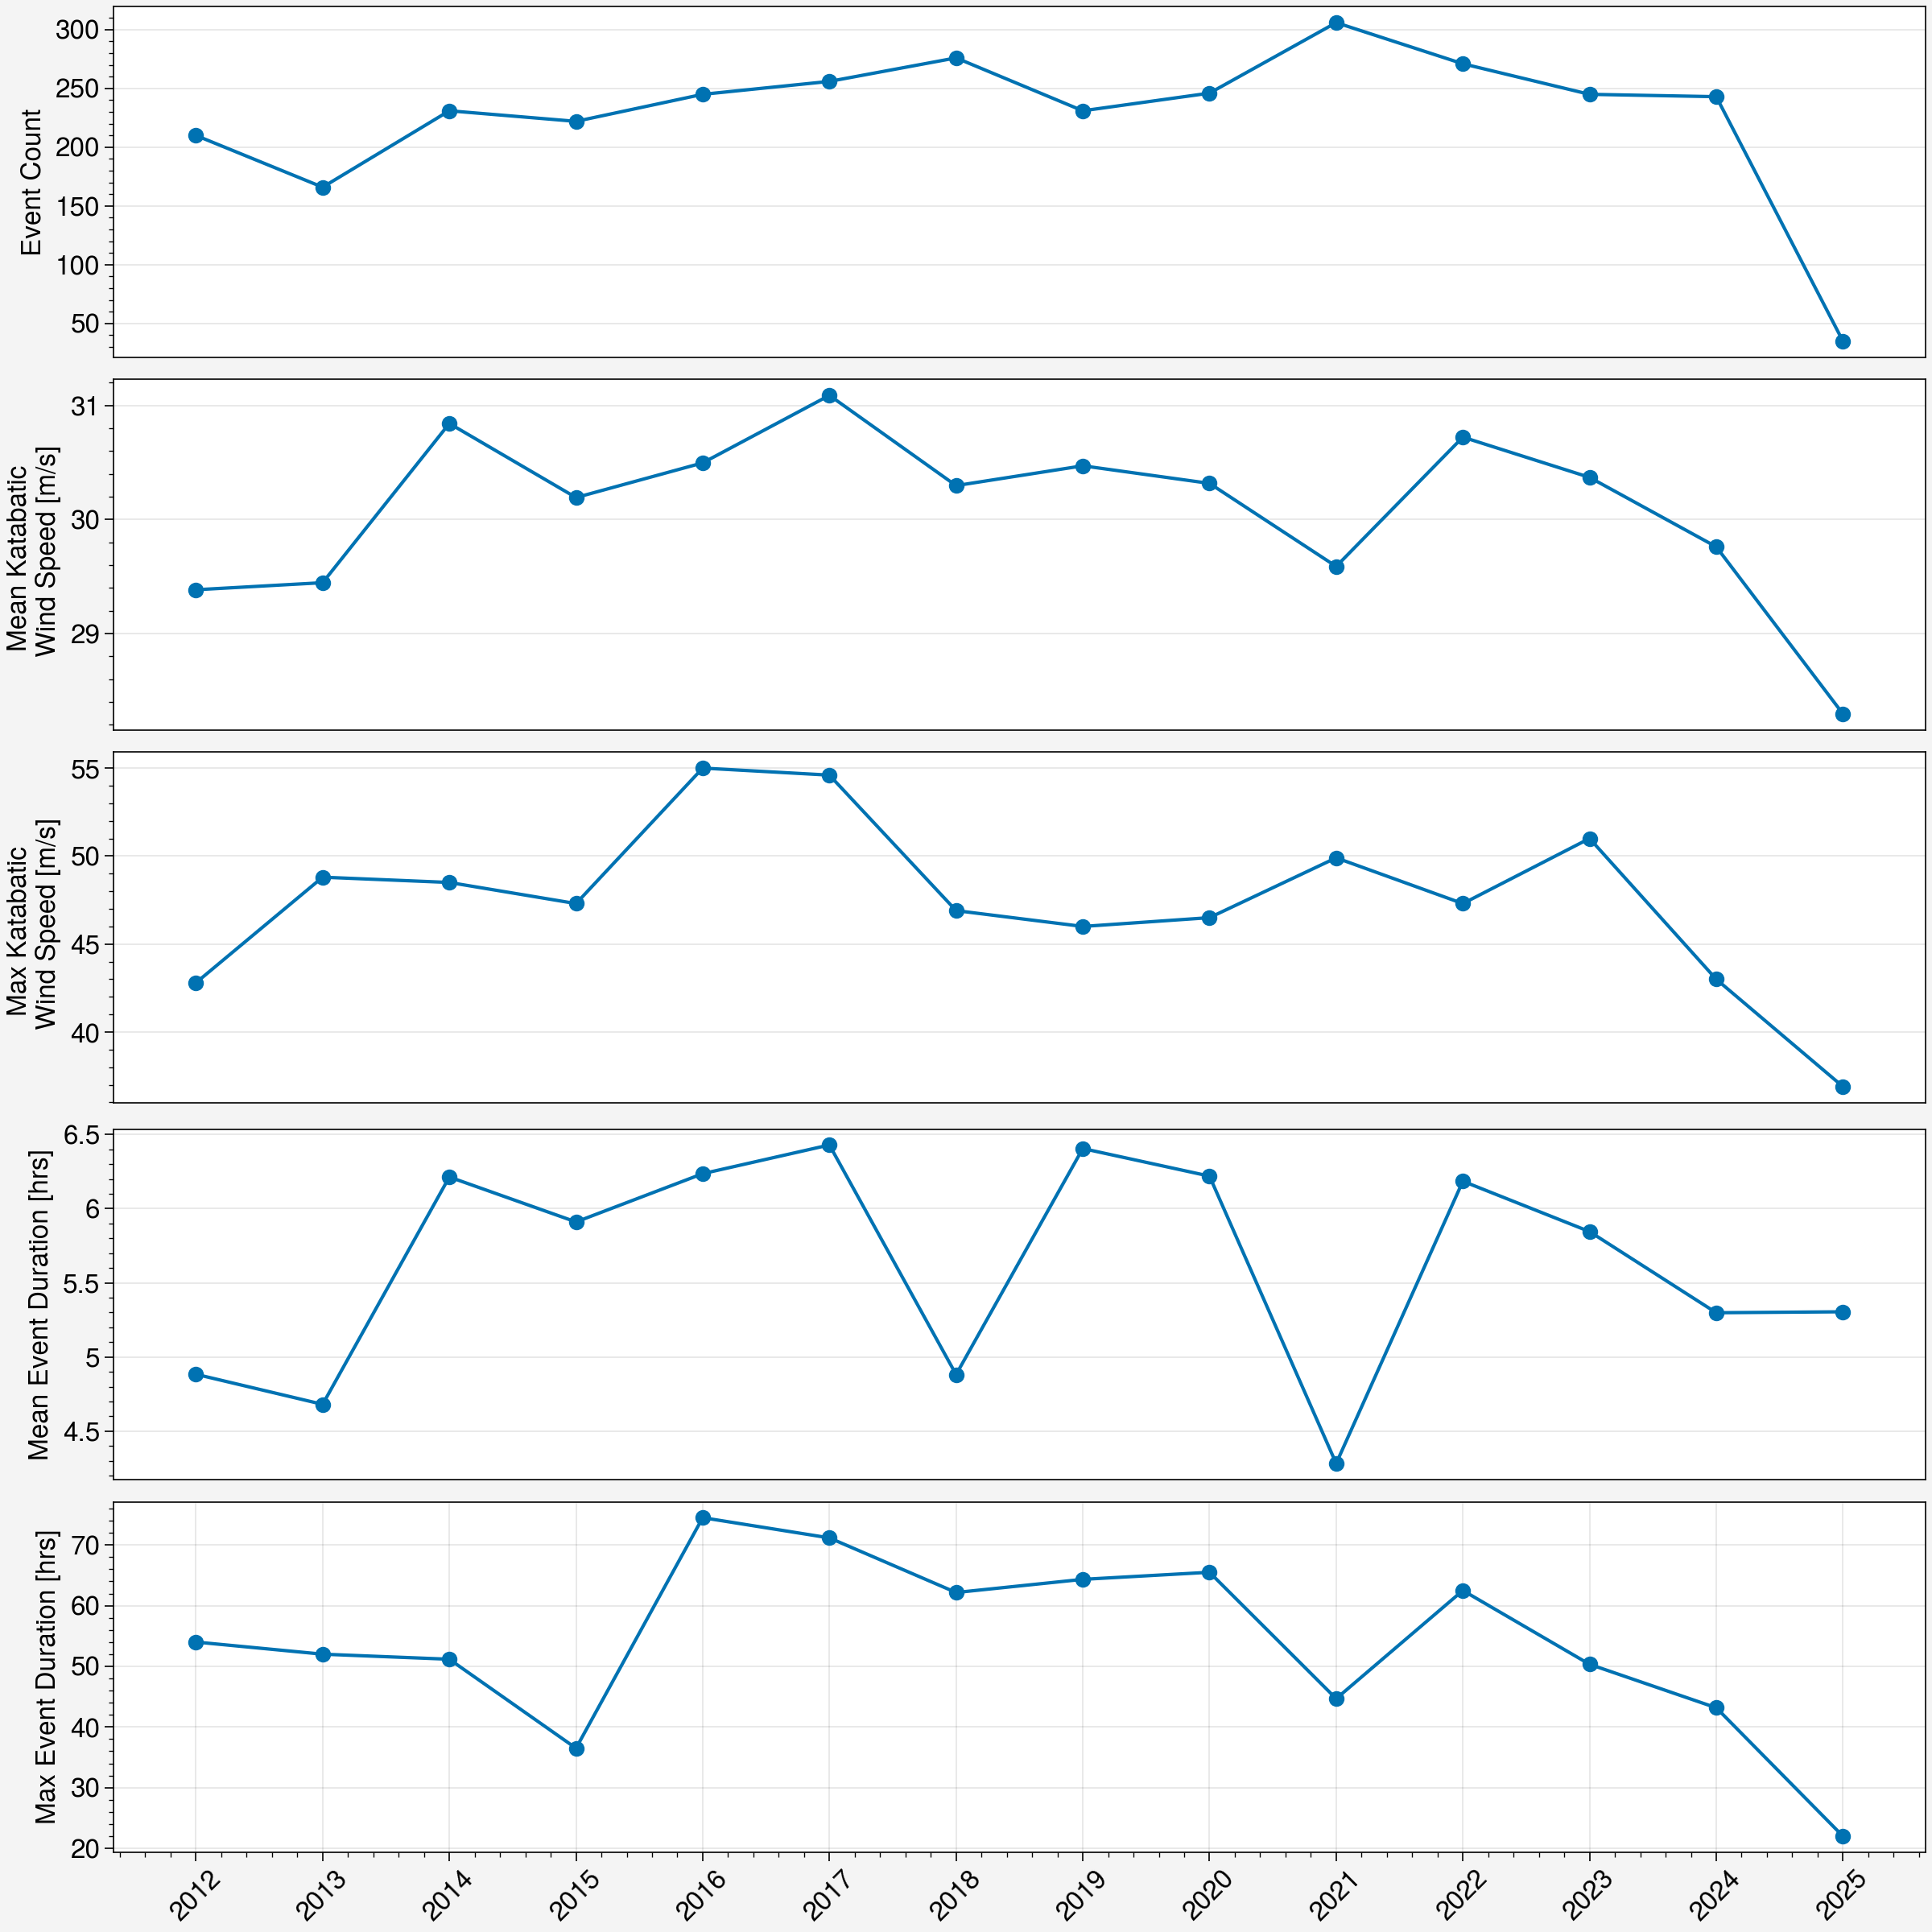

In [64]:
# plot of above calculated quantities 
fig = plt.figure(figsize=(12,12),constrained_layout=True)
plt.subplot(5,1,1)
plt.plot(years,events_per_year,linestyle='-',marker='o')
ax = plt.gca()
plt.xticks([]);
plt.ylabel('Event Count')

plt.subplot(5,1,2)
plt.plot(years,mean_wind_speed,linestyle='-',marker='o')
ax = plt.gca()
plt.xticks([]);
plt.ylabel('Mean Katabatic \n Wind Speed [m/s]')

plt.subplot(5,1,3)
plt.plot(years,max_wind_speed,linestyle='-',marker='o')
ax = plt.gca()
plt.xticks([]);
plt.ylabel('Max Katabatic \n Wind Speed [m/s]')

plt.subplot(5,1,4)
plt.plot(years,mean_event_duration,linestyle='-',marker='o')
ax = plt.gca()
plt.xticks([]);
plt.ylabel('Mean Event Duration [hrs]')

plt.subplot(5,1,5)
plt.plot(years,max_event_duration,linestyle='-',marker='o')
ax = plt.gca()
plt.xticks(years,rotation=45);
plt.ylabel('Max Event Duration [hrs]')

# plt.savefig('katabatic_wind_info.png')
# plt.savefig('/Users/mackenzie/Documents/Research/PhD/TNB_Research/Figures/AWS_Manuela/katabatic_yearly_info.png',
#             dpi=400,
#             bbox_inches='tight',
#             transparent=True)

This last figure provides a lot of useful information on katabatic wind events. We can see that mean katabatic wind duration ranges from approx 4-6.5 hours, but max event durations can last up to 60-70 hours in extreme cases. Mean wind speeds are around 30 m/s, while max wind speeds can reach 55 m/s. 2021 has the record for the most katabatic wind events. It's interesting that this year also has the lowest mean event duration and low mean wind speed compared to other years. This suggests that 2021 may have been characterized by katabatic wind events that had burst like activity. 

### Monthly Anomalies 

In [26]:
ds

<xarray.Dataset> Size: 43MB
Dimensions:            (time: 679392)
Coordinates:
  * time               (time) datetime64[ns] 5MB 2012-02-01 ... 2024-12-31T23...
    index              (time) float64 5MB ...
Data variables:
    temp               (time) float64 5MB ...
    pressure           (time) float64 5MB ...
    wind_speed         (time) float64 5MB nan nan nan nan ... 12.9 11.3 nan nan
    wind_dir           (time) float64 5MB ...
    relative_humidity  (time) float64 5MB ...
    delta-temp         (time) float64 5MB ...

In [27]:
# 1. Monthly mean time series from 10-minute data
ds_mon = ds.resample(time='MS').mean()
# 'MS' = month start; use 'M' if you prefer month end labels

# 2. Monthly climatology over 2012-2024
wind_speed_clim = ds_mon['wind_speed'].groupby('time.month').mean('time')

# 3. Monthly anomalies
wind_speed_anom = ds_mon['wind_speed'].groupby('time.month') - wind_speed_clim

In [28]:
wind_speed_anom

<xarray.DataArray 'wind_speed' (time: 155)> Size: 1kB
array([ 1.25315302e-01, -2.44599448e+00, -1.19431122e+00, -1.12019940e+00,
       -7.76583360e-01, -1.04962854e+00,  1.94402119e-01, -1.99663795e+00,
       -2.03734076e+00, -2.88800443e+00, -3.69836778e+00, -2.01831710e-01,
       -1.76564000e+00, -1.23267577e+00, -2.50500103e+00, -2.49870680e+00,
       -3.41740266e+00, -2.49002628e+00, -1.37444593e+00, -1.35866620e+00,
       -3.53028811e+00, -3.30314332e+00,  1.93133863e+00,  4.51322503e-01,
        2.31617901e+00,  1.69544307e+00,  4.21297025e+00, -2.39082107e+00,
       -7.38058278e-01,  5.60028679e-01,  3.27500504e-01,  1.23050954e+00,
       -3.77961561e-01, -1.03947434e+00,  2.32477960e-01, -1.25130774e-02,
       -1.62655712e+00, -3.71716431e-01, -2.13800189e+00, -1.27556882e+00,
       -1.49907615e+00,  2.87526438e-01,  1.72496914e+00, -5.58888568e-01,
       -3.23871258e+00,  5.92863621e-01,  1.26658024e+00, -1.28834698e+00,
        3.04457776e-01,  1.55068252e+00, -1.61129997e+00,  1.05176093e+00,
       -5.54228131e-01, -3.08556944e+00, -8.90375841e-01,  8.24275973e-01,
        2.30267407e+00,  2.93252797e+00, -6.66513873e-01, -1.29886755e+00,
        4.64985542e-01,  2.11379548e-01,  2.59889678e+00,  1.08104444e+00,
        3.74727714e-03,  2.96669566e+00,  3.04683294e+00,  3.20274876e+00,
       -7.07843401e-01, -2.19769548e+00, -1.06605864e+00, -1.18299029e+00,
       -1.85815518e-01, -4.90296864e-01,  3.98964340e+00, -4.54914854e-01,
       -7.68579112e-01,  9.71300186e-01, -2.00691701e-01, -2.16487916e-01,
       -1.01674797e+00,  1.38460217e+00,  8.58771809e-01, -2.73563261e-02,
        5.00872633e-01,  7.92533413e-01,  2.18714910e+00, -4.81449192e-01,
        4.27448802e+00, -8.31377385e-01, -1.86674233e+00,  3.41596579e+00,
        5.55643353e-01, -2.81548974e-02, -4.31615822e-01, -8.84619697e-01,
       -3.24721887e+00,  1.67788498e-01,  2.75571391e+00,  2.76701631e+00,
        2.11489311e+00, -1.09296152e+00, -6.37724730e-01, -2.06577433e+00,
        3.32544513e+00, -4.59289157e-01,  1.06259279e+00,  1.74146407e+00,
        4.25209026e-01, -7.10202094e-01, -2.62575599e+00,  1.16597464e+00,
        2.56929126e+00, -1.94852103e-02, -2.95480232e+00, -1.64188690e+00,
        4.27093576e+00,  6.49692325e-01,  5.92554707e-01,  1.37446877e+00,
       -6.23048769e-01, -1.28705678e-01, -1.61909320e+00,  3.39207088e+00,
       -2.66834763e+00,  5.11067074e+00,  1.17552482e+00,  3.16753986e+00,
       -2.31118491e-01,  1.57684574e+00, -5.49664220e-01,  6.46799240e-02,
        9.76827162e-01,  5.39394680e-01, -2.14590646e+00, -1.18659032e+00,
       -7.64842043e-02, -1.57917035e+00,  1.74851384e+00, -1.47136064e-01,
        9.64457226e-01,  5.03252319e-01, -1.24569574e+00,  1.26459036e+00,
        2.33443382e+00,  4.22369591e-01, -1.90500368e+00, -4.96167545e-02,
        1.53633987e+00,  2.51997027e-01, -2.92960508e-01, -3.85556199e+00,
       -2.79142665e-01,  2.27597749e+00,  1.71359995e+00])
Coordinates:
  * time     (time) datetime64[ns] 1kB 2012-02-01 2012-03-01 ... 2024-12-01
    month    (time) int64 1kB 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12

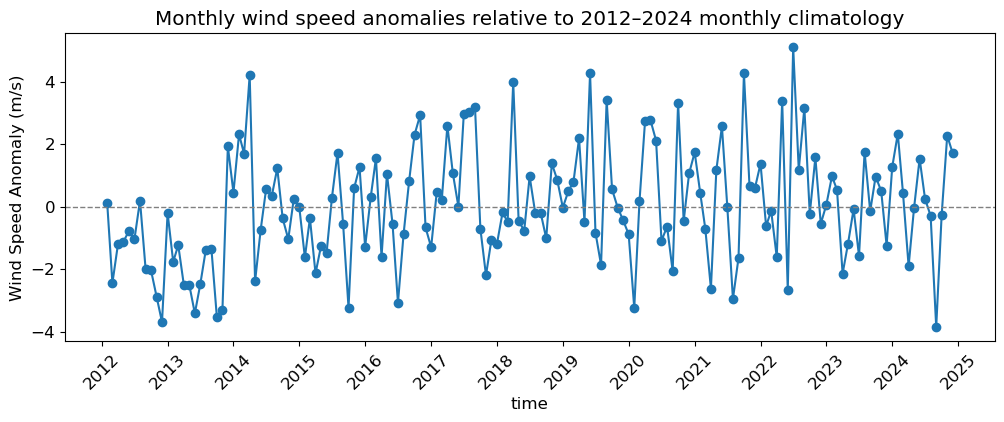

In [44]:
fig, ax = plt.subplots(figsize=(12, 4))
wind_speed_anom.plot(ax=ax,marker='o')
ax.axhline(0, color='grey', lw=1, linestyle='dashed')
ax.set_ylabel('Wind Speed Anomaly (m/s)')
ax.set_title('Monthly wind speed anomalies relative to 2012–2024 monthly climatology')
ax.xaxis.set_major_locator(mdates.YearLocator());
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'));

plt.xticks(rotation=45);
plt.show()

In [ ]:
# seasonal anomalies 
# Seasonal means from monthly data
# selecting data starting in March 2012 to allow creation of whole season from the start 
ds_seas = ds.sel(time=slice('2012-03',None)).resample(time='QS-DEC').mean()
# QS-DEC makes DJF, MAM, JJA, SON seasons starting in Dec

wind_speed_seasonal_clim = ds_seas['wind_speed'].groupby('time.season').mean('time')
wind_speed_seasonal_anom = ds_seas['wind_speed'].groupby('time.season') - wind_speed_seasonal_clim

In [37]:
ds.sel(time=slice('2012-03',None))

<xarray.Dataset> Size: 43MB
Dimensions:            (time: 675216)
Coordinates:
  * time               (time) datetime64[ns] 5MB 2012-03-01 ... 2024-12-31T23...
    index              (time) float64 5MB ...
Data variables:
    temp               (time) float64 5MB ...
    pressure           (time) float64 5MB ...
    wind_speed         (time) float64 5MB 26.7 24.3 26.9 28.1 ... 11.3 nan nan
    wind_dir           (time) float64 5MB ...
    relative_humidity  (time) float64 5MB ...
    delta-temp         (time) float64 5MB ...

In [40]:
wind_speed_seasonal_anom

<xarray.DataArray 'wind_speed' (time: 52)> Size: 416B
array([-1.59113396, -0.54142344, -2.30466682, -1.84099782, -2.07451238,
       -2.416414  , -2.73967397,  1.62348524,  1.13919909,  0.05840184,
       -0.06607053, -0.34805555, -1.25221694,  0.18947189, -1.09265387,
        0.22826983,  0.35138246, -1.52055174,  2.02301412, -0.45030651,
        1.28335738,  2.02741761,  0.0906773 , -0.75180366,  0.98295911,
        0.00893418,  0.03900542,  0.52351661,  0.81806312,  0.484774  ,
        1.30626101, -1.34518556,  1.88750395,  0.10682432,  0.30038831,
        1.17948589, -0.70264928, -0.16407858,  1.12739003,  0.56475385,
        0.57147175,  1.24715959,  1.48572373,  0.21847565, -0.91782893,
        0.03217157,  0.44632817,  0.88777814, -0.49559539,  0.48731275,
       -0.61572287, -0.48941609])
Coordinates:
  * time     (time) datetime64[ns] 416B 2012-03-01 2012-06-01 ... 2024-12-01
    season   (time) object 416B 'MAM' 'JJA' 'SON' 'DJF' ... 'JJA' 'SON' 'DJF'

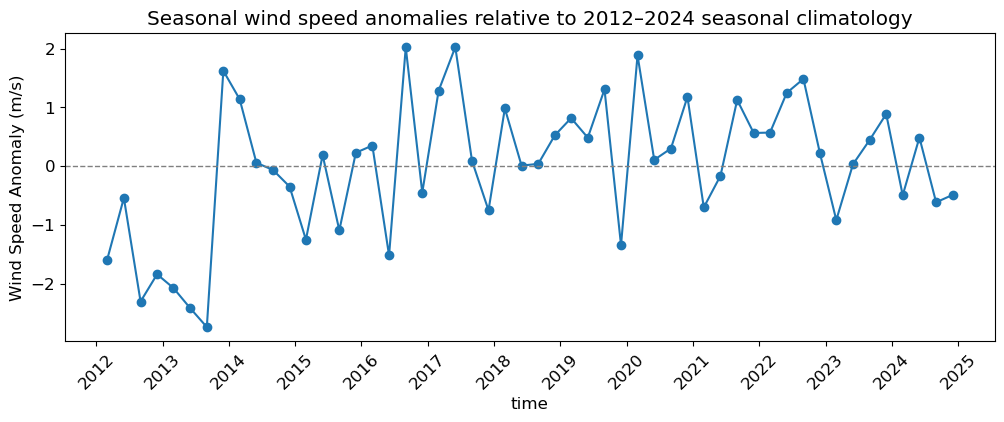

In [43]:
fig, ax = plt.subplots(figsize=(12, 4))
wind_speed_seasonal_anom.plot(ax=ax,marker='o')
ax.axhline(0, color='grey', lw=1, linestyle='dashed')
ax.set_ylabel('Wind Speed Anomaly (m/s)')
ax.set_title('Seasonal wind speed anomalies relative to 2012–2024 seasonal climatology')
ax.xaxis.set_major_locator(mdates.YearLocator());
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'));

plt.xticks(rotation=45);
plt.show()

In [45]:
anom_2d = wind_speed_anom.assign_coords(
    year=wind_speed_anom['time'].dt.year,
    month=wind_speed_anom['time'].dt.month
).set_index(time=['year', 'month']).unstack('time')

In [46]:
anom_2d

<xarray.DataArray 'wind_speed' (year: 13, month: 12)> Size: 1kB
array([[            nan,  1.25315302e-01, -2.44599448e+00,
        -1.19431122e+00, -1.12019940e+00, -7.76583360e-01,
        -1.04962854e+00,  1.94402119e-01, -1.99663795e+00,
        -2.03734076e+00, -2.88800443e+00, -3.69836778e+00],
       [-2.01831710e-01, -1.76564000e+00, -1.23267577e+00,
        -2.50500103e+00, -2.49870680e+00, -3.41740266e+00,
        -2.49002628e+00, -1.37444593e+00, -1.35866620e+00,
        -3.53028811e+00, -3.30314332e+00,  1.93133863e+00],
       [ 4.51322503e-01,  2.31617901e+00,  1.69544307e+00,
         4.21297025e+00, -2.39082107e+00, -7.38058278e-01,
         5.60028679e-01,  3.27500504e-01,  1.23050954e+00,
        -3.77961561e-01, -1.03947434e+00,  2.32477960e-01],
       [-1.25130774e-02, -1.62655712e+00, -3.71716431e-01,
        -2.13800189e+00, -1.27556882e+00, -1.49907615e+00,
         2.87526438e-01,  1.72496914e+00, -5.58888568e-01,
        -3.23871258e+00,  5.92863621e-01,  1.26658024e+00],
       [-1.28834698e+00,  3.04457776e-01,  1.55068252e+00,
        -1.61129997e+00,  1.05176093e+00, -5.54228131e-01,
        -3.08556944e+00, -8.90375841e-01,  8.24275973e-01,
         2.30267407e+00,  2.93252797e+00, -6.66513873e-01],
...
       [-8.84619697e-01, -3.24721887e+00,  1.67788498e-01,
         2.75571391e+00,  2.76701631e+00,  2.11489311e+00,
        -1.09296152e+00, -6.37724730e-01, -2.06577433e+00,
         3.32544513e+00, -4.59289157e-01,  1.06259279e+00],
       [ 1.74146407e+00,  4.25209026e-01, -7.10202094e-01,
        -2.62575599e+00,  1.16597464e+00,  2.56929126e+00,
        -1.94852103e-02, -2.95480232e+00, -1.64188690e+00,
         4.27093576e+00,  6.49692325e-01,  5.92554707e-01],
       [ 1.37446877e+00, -6.23048769e-01, -1.28705678e-01,
        -1.61909320e+00,  3.39207088e+00, -2.66834763e+00,
         5.11067074e+00,  1.17552482e+00,  3.16753986e+00,
        -2.31118491e-01,  1.57684574e+00, -5.49664220e-01],
       [ 6.46799240e-02,  9.76827162e-01,  5.39394680e-01,
        -2.14590646e+00, -1.18659032e+00, -7.64842043e-02,
        -1.57917035e+00,  1.74851384e+00, -1.47136064e-01,
         9.64457226e-01,  5.03252319e-01, -1.24569574e+00],
       [ 1.26459036e+00,  2.33443382e+00,  4.22369591e-01,
        -1.90500368e+00, -4.96167545e-02,  1.53633987e+00,
         2.51997027e-01, -2.92960508e-01, -3.85556199e+00,
        -2.79142665e-01,  2.27597749e+00,  1.71359995e+00]])
Coordinates:
  * year     (year) int64 104B 2012 2013 2014 2015 2016 ... 2021 2022 2023 2024
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

In [47]:
ws_2d = ds_mon['wind_speed'].assign_coords(
    year=ds_mon.time.dt.year,
    month=ds_mon.time.dt.month
).set_index(time=['year', 'month']).unstack('time')

In [49]:
ws_2d

<xarray.DataArray 'wind_speed' (year: 13, month: 12)> Size: 1kB
array([[        nan, 15.17119285, 16.67277616, 19.04141005, 18.43453608,
        18.67388233, 18.39508068, 17.8494061 , 16.6018407 , 13.21188929,
         8.13791667,  3.93600403],
       [ 7.37094352, 13.28023755, 17.88609487, 17.73072024, 17.05602869,
        16.03306302, 16.95468295, 16.28055805, 17.23981246, 11.71894194,
         7.72277778,  9.56571044],
       [ 8.02409774, 17.36205656, 20.81421371, 24.44869152, 17.16391441,
        18.71240741, 20.0047379 , 17.98250448, 19.82898819, 14.87126849,
         9.98644676,  7.86684978],
       [ 7.56026216, 13.41932044, 18.74705421, 18.09771938, 18.27916667,
        17.95138953, 19.73223566, 19.37997312, 18.03959009, 12.01051747,
        11.61878472,  8.90095206],
       [ 6.28442825, 15.35033533, 20.66945316, 18.6244213 , 20.60649642,
        18.89623755, 16.35913978, 16.76462814, 19.42275463, 17.55190412,
        13.95844907,  6.96785794],
       [ 6.27390769, 15.5108631 , 19.33015019, 22.83461806, 20.63577992,
        19.45421296, 22.41140488, 20.70183692, 21.80122742, 14.54138665,
         8.82822562,  6.56831317],
       [ 6.38978495, 14.86006203, 18.62847378, 24.22536467, 19.09982063,
        18.68188657, 20.41600941, 17.45431228, 18.38199074, 14.23248208,
        12.41052327,  8.49314363],
       [ 7.54541891, 15.54675019, 19.91130406, 22.42287037, 19.07328629,
        23.7249537 , 18.61333184, 15.78826165, 22.01444444, 15.8048734 ,
        10.9977662 ,  7.20275599],
       [ 6.68815554, 11.79865868, 19.28655914, 22.99143519, 22.32175179,
        21.5653588 , 18.3517477 , 17.01727925, 16.53270433, 18.57467518,
        10.56663194,  8.69696461],
       [ 9.3142393 , 15.47108658, 18.40856855, 17.60996528, 20.72071013,
        22.01975694, 19.42522401, 14.70020166, 16.95659175, 19.52016581,
        11.67561343,  8.22692652],
       [ 8.94724401, 14.42282878, 18.99006496, 18.61662807, 22.94680636,
        16.78211806, 24.55537996, 18.83052879, 21.76601852, 15.01811156,
        12.60276684,  7.0847076 ],
       [ 7.63745516, 16.02270471, 19.65816532, 18.08981481, 18.36814516,
        19.37398148, 17.86553888, 19.40351781, 18.45134259, 16.21368728,
        11.52917342,  6.38867608],
       [ 8.83736559, 17.38031138, 19.54114023, 18.33071759, 19.50511873,
        20.98680556, 19.69670625, 17.36204347, 14.74291667, 14.97008739,
        13.30189859,  9.34797176]])
Coordinates:
  * year     (year) int64 104B 2012 2013 2014 2015 2016 ... 2021 2022 2023 2024
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12

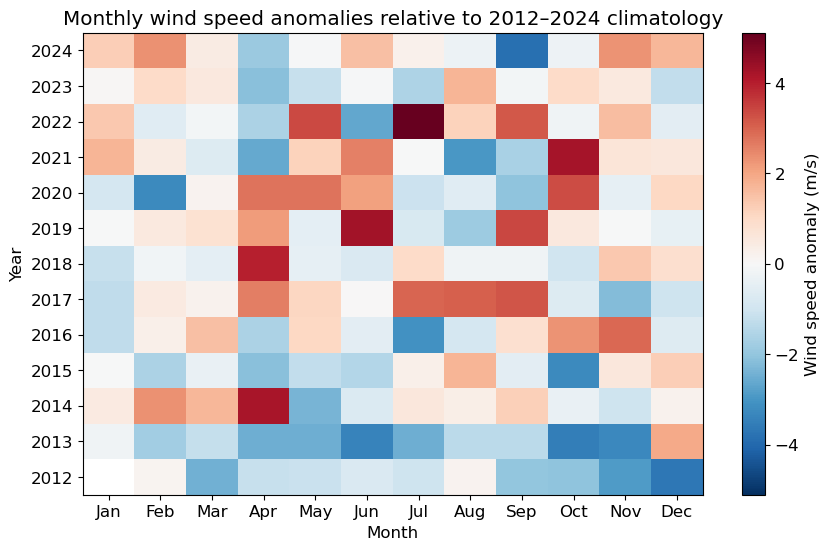

In [62]:
fig, ax = plt.subplots(figsize=(10, 6))

anom_2d.plot(
    ax=ax,
    x='month',
    y='year',
    cmap='RdBu_r',
    center=0,
    cbar_kwargs={'label': 'Wind speed anomaly (m/s)'}
)

# --- Force all years to show ---
years = anom_2d.year.values
ax.set_yticks(years)
ax.set_yticklabels(years)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])

ax.set_title('Monthly wind speed anomalies relative to 2012–2024 climatology')
ax.set_xlabel('Month')
ax.set_ylabel('Year')


plt.show()

### Box plots 

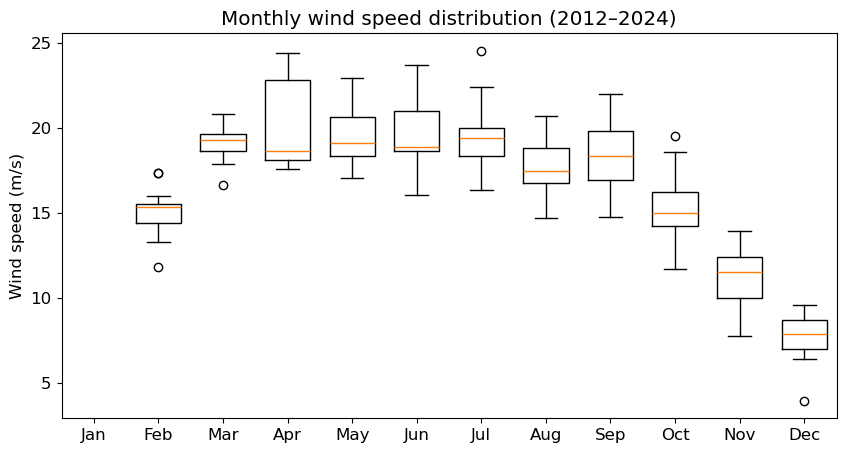

In [66]:
fig, ax = plt.subplots(figsize=(10, 5))

data = [ws_2d.sel(month=m).values for m in range(1, 13)]

bp = ax.boxplot(
    data,
    widths=0.7,
    showfliers=True
)

# ax.axhline(0, color='k', lw=0.8, zorder=0)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel('Wind speed (m/s)')
ax.set_title('Monthly wind speed distribution (2012–2024)')

plt.show()

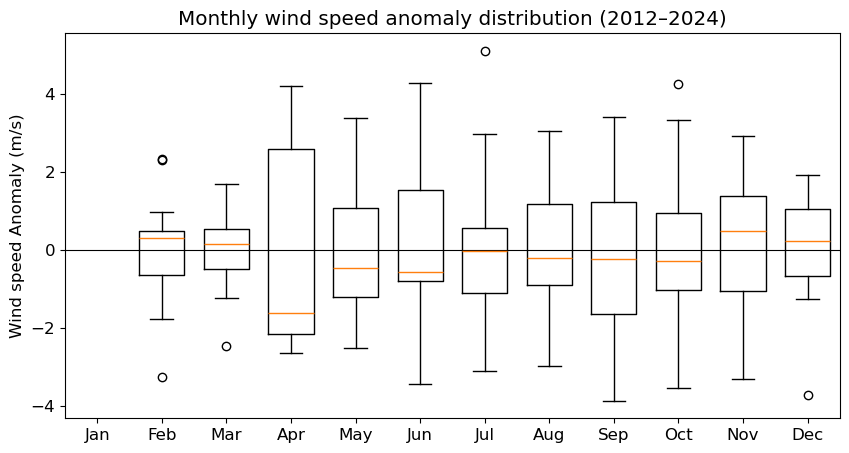

In [67]:
fig, ax = plt.subplots(figsize=(10, 5))

data = [anom_2d.sel(month=m).values for m in range(1, 13)]

bp = ax.boxplot(
    data,
    widths=0.7,
    showfliers=True
)

ax.axhline(0, color='k', lw=0.8, zorder=0)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel('Wind speed Anomaly (m/s)')
ax.set_title('Monthly wind speed anomaly distribution (2012–2024)')

plt.show()

### Yearly Climatology + Individual Years 

In [51]:
ws_clim = ds_mon['wind_speed'].groupby('time.month').mean('time')

In [55]:
ws_std = ds_mon['wind_speed'].groupby('time.month').std('time')

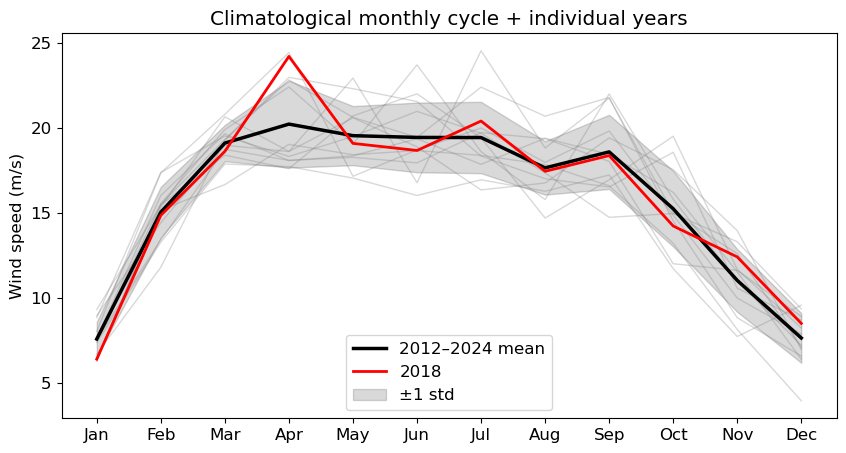

In [56]:
fig, ax = plt.subplots(figsize=(10,5))

# Plot individual years (faint)
for yr in ws_2d.year.values:
    ax.plot(
        ws_2d.month,
        ws_2d.sel(year=yr),
        color='gray',
        alpha=0.3,
        linewidth=1
    )

# Plot climatology (bold)
ax.plot(
    ws_clim.month,
    ws_clim,
    color='k',
    linewidth=2.5,
    label='2012–2024 mean'
)

ax.set_xticks(range(1,13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])

ax.set_ylabel('Wind speed (m/s)')
ax.set_title('Climatological monthly cycle + individual years')

ax.plot(
    ws_2d.month,
    ws_2d.sel(year=2018),
    color='red',
    linewidth=2,
    label='2018'
)

ax.fill_between(
    ws_clim.month,
    ws_clim - ws_std,
    ws_clim + ws_std,
    color='k',
    alpha=0.15,
    label='±1 std'
)

ax.legend()
plt.show()